# OP_MK.ipynb

Clean MK-method workflow updated to follow the paper-style implementation more closely:

- use the DAP best-fitting stellar continuum cube, not `modelcube.binned_flux`;
- recast the full spectral cube onto the disk-aligned frame;
- construct `stellar_sb_recast` from the recast cube itself;
- save `light_profile_x` for every slit;
- fit slit spectra with pPXF using `moments=2`, `degree=8`, `mdegree=0`;
- take `V_losvd = V_ppxf` directly;
- convert the fitted MK slope to physical `Omega_p` and show it in the plot.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, pickle, gzip
from pathlib import Path
from scipy.ndimage import map_coordinates, generic_filter

from marvin import config
from marvin.tools import Maps
from marvin.tools.cube import Cube

from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
from mangadap.proc.templatelibrary import TemplateLibrary

%config InlineBackend.figure_formats = ['svg']

C_KMS = 299792.458

CACHE_ROOT = Path("/home/jinelfy/TW_external/intermediate_cache")
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
MASTER_CSV = CACHE_ROOT / "master_table.csv"
TW_CENTER_DIR = CACHE_ROOT / "tw_center"
TW_CENTER_DIR.mkdir(parents=True, exist_ok=True)


def load_json(path):
    with open(Path(path), "r", encoding="utf-8") as f:
        return json.load(f)


def load_ellipse_result(plateifu, outdir=ELLIPSE_DIR):
    infile = Path(outdir) / f"ellipse_{plateifu}.json"
    with open(infile, "r", encoding="utf-8") as f:
        return json.load(f)


def get_float_from_master(row, colname, default=np.nan):
    if colname not in row.index:
        return default
    val = row[colname]
    return float(val) if pd.notna(val) else default


def signed_axis_diff_deg(pa1, pa2):
    d = (float(pa1) - float(pa2)) % 180.0
    if d > 90.0:
        d -= 180.0
    return d


def infer_inclination_from_master_or_ellipticity(row, ellipticity=None):
    """Return inclination in degrees. Prefer explicit master-table columns; otherwise use cos(i)=q=1-e."""
    for col in [
        "inclination_deg", "inc_deg", "i_deg", "NSA_ELPETRO_TH50_INCLINATION",
        "nsa_inclination", "ba_inclination_deg"
    ]:
        val = get_float_from_master(row, col, default=np.nan)
        if np.isfinite(val):
            return float(val)
    if ellipticity is None or not np.isfinite(ellipticity):
        return np.nan
    q = np.clip(1.0 - float(ellipticity), 0.05, 1.0)
    return float(np.degrees(np.arccos(q)))


def infer_kpc_per_arcsec(maps, row=None):
    """Try several Marvin/NSA fields; fallback uses astropy cosmology if available."""
    if row is not None:
        for col in ["kpc_per_arcsec", "KpcPerArcsec", "nsa_kpc_per_arcsec"]:
            val = get_float_from_master(row, col, default=np.nan)
            if np.isfinite(val):
                return float(val)
    for attr in ["nsa"]:
        obj = getattr(maps, attr, None)
        if isinstance(obj, dict):
            for key in ["elpetro_th50_kpc", "elpetro_th50_r", "z"]:
                pass
    try:
        from astropy.cosmology import Planck15 as cosmo
        z = float(maps.nsa["z"])
        return float(cosmo.kpc_proper_per_arcmin(z).value / 60.0)
    except Exception:
        raise RuntimeError("Could not infer kpc_per_arcsec. Add a kpc_per_arcsec column to master_table.csv.")
def _style_for_yabs(yabs):
    """Consistent style for different slit offsets.

    The absolute slit offset sets the color, so +Y and -Y from the
    same slit pair use the same color. Positive-Y points are open
    symbols; negative-Y points are filled symbols.
    """
    y = int(round(abs(float(yabs))))
    cmap = {0:"black", 1: "orange", 2: "red", 3: "green", 4: "blue"}
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    c = cmap.get(y, color_cycle[y % len(color_cycle)])
    return {
        "color": c,
        "label_pos": rf"$+{y}''$",
        "label_neg": rf"$-{y}''$",
        "label_sym": rf"$\pm {y}''$",
    }


In [20]:
# =========================================================
# 0. Basic setup
# =========================================================
galaxy_id = "8312-12702"
pixscale = 0.5  # arcsec / pixel for MaNGA reconstructed cube
slit_width_arcsec = 2.0
slit_centers_arcsec = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

master_table = pd.read_csv(MASTER_CSV)
master_row = master_table[master_table["plateifu"].astype(str) == galaxy_id].iloc[0]

Vsys_ref = 0 #get_float_from_master(master_row, "Vsys_ref")
PA_disk_kin = get_float_from_master(master_row, "PA_disk_kin_mode_deg_0_180") - 90.0
Xc_best_arcsec = 0 #get_float_from_master(master_row, "Xc_best_arcsec")
Yc_best_arcsec = 0 #get_float_from_master(master_row, "Yc_best_arcsec")
Vsys_best = 0 #get_float_from_master(master_row, "Vsys_best")

ellipse_payload = load_ellipse_result(galaxy_id)
PA_bar = float(ellipse_payload["PA_bar_deg_0_180"])
a_max = float(ellipse_payload["a_max_arcsec"])

# Prefer e_disk already stored in the master table. Otherwise use values from the ellipse payload if present.
e_disk = get_float_from_master(master_row, "e_disk", default=np.nan)
if not np.isfinite(e_disk):
    for key in ["e_disk", "ellipticity", "ellipticity_disk"]:
        if key in ellipse_payload:
            e_disk = float(ellipse_payload[key])
            break

phi_bar_disk = signed_axis_diff_deg(PA_bar, PA_disk_kin)
bar_half_width_arcsec = a_max * abs(np.sin(np.deg2rad(phi_bar_disk)))

print(f"galaxy_id = {galaxy_id}")
print(f"PA_disk_kin = {PA_disk_kin:.3f} deg")
print(f"Xc_best, Yc_best = {Xc_best_arcsec:.3f}, {Yc_best_arcsec:.3f} arcsec")
print(f"Vsys_best = {Vsys_best:.3f} km/s")
print(f"PA_bar = {PA_bar:.3f} deg, a_max = {a_max:.3f} arcsec")
print(f"bar_half_width = {bar_half_width_arcsec:.3f} arcsec")

galaxy_id = 8312-12702
PA_disk_kin = 6.000 deg
Xc_best, Yc_best = 0.000, 0.000 arcsec
Vsys_best = 0.000 km/s
PA_bar = 120.279 deg, a_max = 6.494 arcsec
bar_half_width = 5.920 arcsec


In [49]:
# =========================================================
# 1. Load MaNGA DR17 SPX maps, DAP model cube, DRP IVAR, and LSF/SRES
# =========================================================
def load_manga_maps_modelcube_dr17(
    galaxy_id="8312-12702",
    daptype="SPX-MILESHC-MASTARSSP",
    sas_root="/home/jinelfy/sas",
):
    plate, ifu = galaxy_id.split("-")
    config.mode = "local"
    config.access = "public"
    config.setRelease("DR17")

    base = Path(sas_root) / "dr17/manga/spectro/analysis/v3_1_1/3.1.0" / daptype / plate / ifu
    maps_file = base / f"manga-{galaxy_id}-MAPS-{daptype}.fits.gz"
    if not maps_file.exists():
        raise FileNotFoundError(f"MAPS file not found: {maps_file}")

    maps = Maps(filename=str(maps_file))
    modelcube = maps.getModelCube()
    return maps, modelcube, maps_file


def _safe_value(obj):
    """Return a plain numpy array from Marvin quantities/properties."""
    if obj is None:
        return None
    if hasattr(obj, "value"):
        return np.asarray(obj.value)
    if hasattr(obj, "data"):
        return np.asarray(obj.data)
    return np.asarray(obj)


def extract_drp_flux_ivar(my_cube):
    """
    Extract DRP inverse-variance cube for the observed flux.

    This is used as the uncertainty proxy for the collapsed MK stellar-continuum
    slit spectra.  The MK flux itself is still the DAP stellar continuum model
    cube, but the propagated noise comes from the observed DRP flux IVAR.
    """
    candidates = []
    # Marvin DataModel property route.
    try:
        candidates.append(my_cube.flux.ivar)
    except Exception:
        pass
    # FITS-extension route.  Extension names can differ between Marvin versions.
    for key in ["IVAR", "FLUX_IVAR"]:
        try:
            candidates.append(my_cube.data[key].data)
        except Exception:
            pass
    for cand in candidates:
        arr = _safe_value(cand)
        if arr is not None and arr.ndim == 3:
            return arr.astype(float)
    raise RuntimeError("Could not find a 3-D DRP flux IVAR cube in my_cube.")


def extract_spectral_resolution(my_cube, modelcube=None, wave_obs=None):
    """
    Return MaNGA spectral resolution R(lambda)=lambda/FWHM, if available.

    The preferred source is the DRP CUBE SPECRES extension.  A 1-D SRES vector
    is sufficient for template matching; a 3-D cube is allowed and will later be
    collapsed to a slit-weighted 1-D vector.
    """
    candidates = []
    for key in ["SPECRES", "SRES", "LSF", "PREDISP"]:
        try:
            candidates.append(my_cube.data[key].data)
        except Exception:
            pass
    for attr in ["spectral_resolution", "sres"]:
        try:
            candidates.append(getattr(my_cube, attr))
        except Exception:
            pass
    if modelcube is not None:
        for attr in ["sres", "stellar_sres", "stellarcont_sres"]:
            try:
                candidates.append(getattr(modelcube, attr))
            except Exception:
                pass
    for cand in candidates:
        arr = _safe_value(cand)
        if arr is None:
            continue
        arr = np.asarray(arr, dtype=float)
        if arr.ndim == 1 and (wave_obs is None or arr.size == len(wave_obs)):
            return arr
        if arr.ndim == 3 and (wave_obs is None or arr.shape[0] == len(wave_obs)):
            return arr
    return None


maps, modelcube, maps_file = load_manga_maps_modelcube_dr17(
    galaxy_id=galaxy_id,
    daptype="SPX-MILESHC-MASTARSSP",
    sas_root="/home/jinelfy/sas",
)
my_cube = Cube(plateifu=galaxy_id)

# Paper-style MK input: DAP best-fitting stellar continuum/model cube.
# IMPORTANT: do not use modelcube.binned_flux here.
stellar_model_cube_native = modelcube.stellarcont_fit.value.astype(float)
wave_obs = my_cube.data["WAVE"].data.astype(float)
z = float(maps.nsa["z"])
wave_rest = wave_obs / (1.0 + z)

# New: use the DRP inverse variance and instrumental spectral resolution.
# The IVAR cube is propagated through the same recast/slit-collapse operations.
flux_ivar_native = extract_drp_flux_ivar(my_cube)
sres_native = extract_spectral_resolution(my_cube, modelcube=modelcube, wave_obs=wave_obs)
if sres_native is None:
    print("WARNING: no MaNGA spectral-resolution vector/cube found; template LSF matching will use the nominal MILESHC resolution only.")
else:
    print("Loaded spectral-resolution information with shape", np.shape(sres_native))

stellar_vel = maps.stellar_vel.value.astype(float)
stellar_vel[stellar_vel == 0] = np.nan
ha_flux = maps.emline_gflux_ha_6564.value.astype(float)
ha_flux[ha_flux == 0] = np.nan
ha_vel = maps.emline_gvel_ha_6564.value.astype(float)
ha_vel[ha_vel == 0] = np.nan

assert stellar_model_cube_native.shape[0] == wave_obs.size
assert flux_ivar_native.shape == stellar_model_cube_native.shape
print("Loaded:", maps_file)
print("stellar_model_cube_native shape =", stellar_model_cube_native.shape)
print("flux_ivar_native shape        =", flux_ivar_native.shape)

[WARNING]: path /home/jinelfy/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None. (MarvinUserWarning)


Loaded spectral-resolution information with shape (4563,)
Loaded: /home/jinelfy/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/SPX-MILESHC-MASTARSSP/8312/12702/manga-8312-12702-MAPS-SPX-MILESHC-MASTARSSP.fits.gz
stellar_model_cube_native shape = (4563, 74, 74)
flux_ivar_native shape        = (4563, 74, 74)


In [50]:
# =========================================================
# 2. True-center coordinate system
# =========================================================
def build_xy_arcsec_with_center(shape, x0_pix, y0_pix, pixscale_arcsec=0.5):
    ny, nx = shape
    yy, xx = np.mgrid[:ny, :nx]
    x_arcsec = (xx - x0_pix) * pixscale_arcsec
    y_arcsec = (yy - y0_pix) * pixscale_arcsec
    extent_arcsec = [
        -x0_pix * pixscale_arcsec,
        ((nx - 1) - x0_pix) * pixscale_arcsec,
        -y0_pix * pixscale_arcsec,
        ((ny - 1) - y0_pix) * pixscale_arcsec,
    ]
    cx = int(np.argmin(np.abs(x_arcsec[0, :])))
    cy = int(np.argmin(np.abs(y_arcsec[:, 0])))
    return x_arcsec.astype(float), y_arcsec.astype(float), extent_arcsec, (cy, cx)

ra0, dec0 = my_cube.ra, my_cube.dec
wcs2d = my_cube.wcs.celestial
x0_pix, y0_pix = wcs2d.world_to_pixel_values(ra0, dec0)

x_arcsec, y_arcsec, extent_arcsec, center_index = build_xy_arcsec_with_center(
    shape=stellar_model_cube_native.shape[1:],
    x0_pix=x0_pix,
    y0_pix=y0_pix,
    pixscale_arcsec=pixscale,
)

# Shift to the TW-converged center before recasting/building MK slits.
# Native coordinate grid centered on the original MaNGA/WCS center.
# Do NOT apply Xc_best/Yc_best before recasting.
x_axis_recast0 = x_arcsec[0, :]
y_axis_recast0 = y_arcsec[:, 0]

# These shifted axes are used only after the cube has been recast.
# In this MK coordinate system, the TW-converged center is at (0, 0).
x_axis_mk = x_axis_recast0 - Xc_best_arcsec
y_axis_mk = y_axis_recast0 - Yc_best_arcsec

extent_recast0 = [
    x_axis_recast0[0],
    x_axis_recast0[-1],
    y_axis_recast0[0],
    y_axis_recast0[-1],
]

extent_mk = [
    x_axis_mk[0],
    x_axis_mk[-1],
    y_axis_mk[0],
    y_axis_mk[-1],
]

In [51]:
# =========================================================
# 3. Recast helpers: maps, spectral cubes, variance cubes, and SRES cubes
# =========================================================
def infer_true_center_pix_from_xy(x_arcsec, y_arcsec, pixel_scale=0.5):
    x0_pix = -x_arcsec[0, 0] / pixel_scale
    y0_pix = -y_arcsec[0, 0] / pixel_scale
    return x0_pix, y0_pix


def source_pixel_grid_for_recast(pa_disk_deg, x_arcsec, y_arcsec, pixel_scale=0.5):
    """
    Target grid is disk-aligned. Sample the native grid by rotating target
    coordinates back into the original image frame by +PA_disk.
    """
    x0_pix, y0_pix = infer_true_center_pix_from_xy(x_arcsec, y_arcsec, pixel_scale=pixel_scale)
    theta = np.deg2rad(pa_disk_deg)
    x_old = x_arcsec * np.cos(theta) - y_arcsec * np.sin(theta)
    y_old = x_arcsec * np.sin(theta) + y_arcsec * np.cos(theta)
    x_src_pix = x_old / pixel_scale + x0_pix
    y_src_pix = y_old / pixel_scale + y0_pix
    return x_src_pix, y_src_pix


def sample_2d_with_nan_bilinear(data, x_src_pix, y_src_pix, min_valid_frac=0.999):
    data = np.asarray(data, dtype=float)
    valid = np.isfinite(data)
    data0 = np.where(valid, data, 0.0)
    w0 = valid.astype(float)
    coords = np.vstack([y_src_pix.ravel(), x_src_pix.ravel()])
    data_i = map_coordinates(data0, coords, order=1, mode="constant", cval=0.0).reshape(data.shape)
    w_i = map_coordinates(w0, coords, order=1, mode="constant", cval=0.0).reshape(data.shape)
    out = np.full_like(data_i, np.nan, dtype=float)
    good = w_i >= min_valid_frac
    out[good] = data_i[good] / w_i[good]
    return out, w_i


def sample_2d_variance_bilinear(var, x_src_pix, y_src_pix, min_valid_frac=0.999):
    """
    Bilinear interpolation for an uncorrelated variance map.

    For a flux interpolation f'=sum_i w_i f_i, the variance is
    Var(f')=sum_i w_i^2 Var(f_i).  This is stricter than interpolating the
    variance map itself and is the quantity needed for noise propagation.
    """
    var = np.asarray(var, dtype=float)
    ny, nx = var.shape
    x = np.asarray(x_src_pix, dtype=float)
    y = np.asarray(y_src_pix, dtype=float)

    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    dx = x - x0
    dy = y - y0

    x1 = x0 + 1
    y1 = y0 + 1
    inside = (x0 >= 0) & (x1 < nx) & (y0 >= 0) & (y1 < ny)

    out = np.full_like(x, np.nan, dtype=float)
    valid_weight = np.zeros_like(x, dtype=float)
    var_sum = np.zeros_like(x, dtype=float)

    for yy, xx, ww in [
        (y0, x0, (1.0 - dx) * (1.0 - dy)),
        (y0, x1, dx * (1.0 - dy)),
        (y1, x0, (1.0 - dx) * dy),
        (y1, x1, dx * dy),
    ]:
        ok_index = inside
        vals = np.zeros_like(x, dtype=float)
        vals[ok_index] = var[yy[ok_index], xx[ok_index]]
        ok = ok_index & np.isfinite(vals) & (vals > 0) & np.isfinite(ww) & (ww > 0)
        valid_weight[ok] += ww[ok]
        var_sum[ok] += (ww[ok] ** 2) * vals[ok]

    good = valid_weight >= min_valid_frac
    out[good] = var_sum[good]
    return out, valid_weight


def bilinear_recast_map(data, pa_disk_deg, x_arcsec, y_arcsec, pixel_scale=0.5,
                        min_valid_frac=0.999, preserve_sum=False):
    x_src_pix, y_src_pix = source_pixel_grid_for_recast(
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
    )
    out, vf = sample_2d_with_nan_bilinear(data, x_src_pix, y_src_pix, min_valid_frac=min_valid_frac)
    if preserve_sum:
        s_in, s_out = np.nansum(data), np.nansum(out)
        if np.isfinite(s_in) and np.isfinite(s_out) and s_out != 0:
            out *= s_in / s_out
    return out, vf


def recast_spectral_cube_with_variance(cube3d, var3d, pa_disk_deg, x_arcsec, y_arcsec,
                                       pixel_scale=0.5, min_valid_frac=0.999,
                                       preserve_sum=True, verbose=True):
    """
    Recast a flux cube and propagate an associated variance cube.

    The variance cube should be in the same flux-density units squared as the
    input cube.  If preserve_sum rescales a spectral slice by a factor a, the
    corresponding variance slice is rescaled by a^2.
    """
    cube3d = np.asarray(cube3d, dtype=float)
    var3d = np.asarray(var3d, dtype=float)
    if cube3d.shape != var3d.shape:
        raise ValueError(f"cube3d and var3d must have the same shape: {cube3d.shape} vs {var3d.shape}")

    nw, ny, nx = cube3d.shape
    x_src_pix, y_src_pix = source_pixel_grid_for_recast(
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
    )
    flux_out = np.full_like(cube3d, np.nan, dtype=float)
    var_out = np.full_like(var3d, np.nan, dtype=float)

    for k in range(nw):
        flux_out[k], _ = sample_2d_with_nan_bilinear(
            cube3d[k], x_src_pix, y_src_pix, min_valid_frac=min_valid_frac
        )
        var_out[k], _ = sample_2d_variance_bilinear(
            var3d[k], x_src_pix, y_src_pix, min_valid_frac=min_valid_frac
        )
        if preserve_sum:
            s_in, s_out = np.nansum(cube3d[k]), np.nansum(flux_out[k])
            if np.isfinite(s_in) and np.isfinite(s_out) and s_out != 0:
                a = s_in / s_out
                flux_out[k] *= a
                var_out[k] *= a * a
        if verbose and ((k + 1) % 1000 == 0 or k == nw - 1):
            print(f"  recast flux/variance spectral slice {k + 1}/{nw}")
    return flux_out, var_out


def recast_spectral_resolution(sres, pa_disk_deg, x_arcsec, y_arcsec, pixel_scale=0.5,
                               min_valid_frac=0.999, verbose=True):
    """Recast a 3-D SRES cube if needed; pass through a 1-D SRES vector."""
    if sres is None:
        return None
    sres = np.asarray(sres, dtype=float)
    if sres.ndim == 1:
        return sres.copy()
    if sres.ndim != 3:
        return None
    nw = sres.shape[0]
    x_src_pix, y_src_pix = source_pixel_grid_for_recast(
        pa_disk_deg=pa_disk_deg,
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixel_scale,
    )
    out = np.full_like(sres, np.nan, dtype=float)
    for k in range(nw):
        out[k], _ = sample_2d_with_nan_bilinear(sres[k], x_src_pix, y_src_pix, min_valid_frac=min_valid_frac)
        if verbose and ((k + 1) % 1000 == 0 or k == nw - 1):
            print(f"  recast SRES slice {k + 1}/{nw}")
    return out

  recast flux/variance spectral slice 1000/4563
  recast flux/variance spectral slice 2000/4563
  recast flux/variance spectral slice 3000/4563
  recast flux/variance spectral slice 4000/4563
  recast flux/variance spectral slice 4563/4563


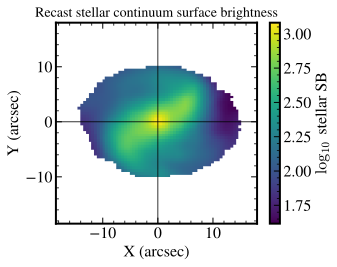

In [52]:
# =========================================================
# 4. Recast the full stellar continuum cube, variance cube, SRES, and stellar_sb_recast
# =========================================================
# Convert DRP IVAR to variance.  Non-positive IVAR is treated as invalid.
flux_var_native = np.full_like(flux_ivar_native, np.nan, dtype=float)
good_ivar = np.isfinite(flux_ivar_native) & (flux_ivar_native > 0)
flux_var_native[good_ivar] = 1.0 / flux_ivar_native[good_ivar]

stellar_model_cube_recast, flux_var_recast = recast_spectral_cube_with_variance(
    cube3d=stellar_model_cube_native,
    var3d=flux_var_native,
    pa_disk_deg=PA_disk_kin,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    pixel_scale=pixscale,
    min_valid_frac=0.999,
    preserve_sum=True,
    verbose=True,
)

sres_recast = recast_spectral_resolution(
    sres=sres_native,
    pa_disk_deg=PA_disk_kin,
    x_arcsec=x_arcsec,
    y_arcsec=y_arcsec,
    pixel_scale=pixscale,
    min_valid_frac=0.999,
    verbose=True,
)

mask_wave = (wave_rest >= 5600.0) & (wave_rest <= 6750.0)
dlam = np.nanmedian(np.diff(wave_rest[mask_wave]))
stellar_sb_recast = np.nansum(stellar_model_cube_recast[mask_wave, :, :], axis=0) * dlam

# Use the cached recast geometry mask if available, but not the cached stellar surface brightness.
fig4_path = Path("./saved_outputs/fig4_out.pkl")
if fig4_path.exists():
    with open(fig4_path, "rb") as f:
        fig4_out = pickle.load(f)
    if "geometry_mask_recast" in fig4_out:
        geometry_mask_recast = np.asarray(fig4_out["geometry_mask_recast"], dtype=bool)
    elif "display_mask_star" in fig4_out:
        geometry_mask_recast = np.asarray(fig4_out["display_mask_star"], dtype=bool)
    else:
        geometry_mask_recast = np.isfinite(stellar_sb_recast) & (stellar_sb_recast > 0)
else:
    fig4_out = None
    geometry_mask_recast = np.isfinite(stellar_sb_recast) & (stellar_sb_recast > 0)

# Require a finite propagated variance for MK pPXF spectra.
var_ok_2d = np.any(np.isfinite(flux_var_recast) & (flux_var_recast > 0), axis=0)
display_mask_star = geometry_mask_recast & np.isfinite(stellar_sb_recast) & (stellar_sb_recast > 0) & var_ok_2d

Recasted = {
    "stellar_cube_recast": stellar_model_cube_recast,
    "stellar_var_recast": flux_var_recast,
    "sres_recast": sres_recast,
    "stellar_sb_recast": stellar_sb_recast,
    "stellar_sigma_recast": stellar_sb_recast,  # compatibility alias
    "display_mask_star": display_mask_star,
    "geometry_mask_recast": geometry_mask_recast,
}

plt.figure(figsize=(5, 4))
plt.imshow(
    np.log10(np.where(display_mask_star, stellar_sb_recast, np.nan)),
    origin="lower",
    extent=extent_mk)
plt.axhline(0, color="k", lw=0.8)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("X (arcsec)")
plt.ylabel("Y (arcsec)")
plt.title("Recast stellar continuum surface brightness")
plt.colorbar(label=r"$\log_{10}$ stellar SB")
plt.tight_layout()
plt.show()

In [53]:
# =========================================================
# 5. Build explicit pseudo-slits from the recast cube, with propagated noise and LSF
# =========================================================
def select_slit_boxes(y_axis, y_center_arcsec, slit_width_arcsec=2.0):
    half_w = 0.5 * slit_width_arcsec
    return np.abs(y_axis - y_center_arcsec) <= (half_w + 1e-12)


def find_symmetric_x_max(valid_mask, row_sel, x_axis, x_center_arcsec=0.0):
    row_idx = np.where(row_sel)[0]
    if len(row_idx) == 0:
        return None
    col_ok = np.all(valid_mask[row_idx, :], axis=0)
    if not np.any(col_ok):
        return None
    x0_idx = int(np.argmin(np.abs(x_axis - x_center_arcsec)))
    if not col_ok[x0_idx]:
        return None
    left = x0_idx
    while left - 1 >= 0 and col_ok[left - 1]:
        left -= 1
    right = x0_idx
    while right + 1 < len(col_ok) and col_ok[right + 1]:
        right += 1
    dx = min(x0_idx - left, right - x0_idx)
    if dx < 1:
        return None
    return x0_idx, x0_idx - dx, x0_idx + dx


def collapse_sres_for_slit(sres_recast, wave_obs, slit_mask, stellar_sb_recast=None):
    """
    Return a slit-weighted 1-D spectral-resolution vector R(lambda).

    If sres_recast is already 1-D, simply return it.  If it is 3-D, take a
    brightness-weighted median/mean over the same slit mask used for the MK
    spectrum.
    """
    if sres_recast is None:
        return None
    sres = np.asarray(sres_recast, dtype=float)
    if sres.ndim == 1:
        return sres.copy()
    if sres.ndim != 3:
        return None
    pix = np.where(slit_mask)
    if len(pix[0]) == 0:
        return None
    vals = sres[:, pix[0], pix[1]]
    if stellar_sb_recast is not None:
        w = np.asarray(stellar_sb_recast[pix[0], pix[1]], dtype=float)
        w[~np.isfinite(w) | (w <= 0)] = np.nan
        if np.any(np.isfinite(w)):
            num = np.nansum(vals * w[None, :], axis=1)
            den = np.nansum(np.where(np.isfinite(vals), w[None, :], np.nan), axis=1)
            out = num / den
            return out.astype(float)
    return np.nanmedian(vals, axis=1).astype(float)


def build_mk_slit_1d_from_recast_cube(cube_recast, wave_obs, stellar_sb_recast, valid_mask,
                                      x_axis, y_axis, slit_centers_arcsec,
                                      var_recast=None, sres_recast=None,
                                      slit_width_arcsec=2.0, x_center_arcsec=0.0,
                                      combine="sum", verbose=True):
    out = {
        "wave_obs": np.asarray(wave_obs, dtype=float).copy(),
        "x_axis": np.asarray(x_axis, dtype=float).copy(),
        "y_axis": np.asarray(y_axis, dtype=float).copy(),
        "slit_width_arcsec": float(slit_width_arcsec),
        "slit_centers_arcsec": [float(v) for v in slit_centers_arcsec],
        "slits": [],
        "slit_spectra": [],
        "meta": {"combine": combine, "x_center_arcsec": float(x_center_arcsec)},
    }
    dy = np.nanmedian(np.abs(np.diff(y_axis))) if len(y_axis) > 1 else slit_width_arcsec

    for y0 in slit_centers_arcsec:
        y0 = float(y0)
        slit_id = int(round(y0))
        row_sel = select_slit_boxes(y_axis, y0, slit_width_arcsec=slit_width_arcsec)
        extent = find_symmetric_x_max(valid_mask, row_sel, x_axis, x_center_arcsec=x_center_arcsec)
        if extent is None:
            if verbose:
                print(f"[MK] skip y={y0:+.1f}: no symmetric valid X extent")
            continue
        _, left, right = extent
        col_sel = np.zeros_like(x_axis, dtype=bool)
        col_sel[left:right + 1] = True
        slit_mask = row_sel[:, None] & col_sel[None, :] & valid_mask
        good = slit_mask & np.isfinite(stellar_sb_recast)
        if not np.any(good):
            continue

        flux2d = cube_recast[:, good]
        flux1d = np.nanmean(flux2d, axis=1) if combine == "mean" else np.nansum(flux2d, axis=1)

        var1d = None
        ivar1d = None
        if var_recast is not None:
            var2d = np.asarray(var_recast[:, good], dtype=float)
            if combine == "mean":
                n_eff = np.sum(np.isfinite(var2d) & (var2d > 0), axis=1).astype(float)
                var1d = np.nansum(var2d, axis=1) / np.maximum(n_eff, 1.0) ** 2
            else:
                var1d = np.nansum(var2d, axis=1)
            var1d[~np.isfinite(var1d) | (var1d <= 0)] = np.nan
            ivar1d = np.full_like(var1d, np.nan, dtype=float)
            ok = np.isfinite(var1d) & (var1d > 0)
            ivar1d[ok] = 1.0 / var1d[ok]

        sres1d = collapse_sres_for_slit(sres_recast, wave_obs, good, stellar_sb_recast=stellar_sb_recast)

        # The light profile actually used for <X>.
        x_seg = x_axis[left:right + 1].astype(float)
        light_profile_x = np.nansum(stellar_sb_recast[row_sel, left:right + 1], axis=0) * dy
        den = np.trapz(light_profile_x, x_seg)
        num = np.trapz(x_seg * light_profile_x, x_seg)
        X_mean_arcsec = num / den if np.isfinite(den) and den != 0 else np.nan

        ent = {
            "slit_id": slit_id,
            "label": f"{slit_id:+d}" if slit_id != 0 else "0",
            "y_offset_arcsec": y0,
            "slit_width_arcsec": float(slit_width_arcsec),
            "x_left_arcsec": float(x_axis[left]),
            "x_right_arcsec": float(x_axis[right]),
            "x_center_arcsec": float(x_center_arcsec),
            "n_spaxels": int(np.count_nonzero(good)),
            "x_profile_arcsec": x_seg.copy(),
            "light_profile_x": light_profile_x.astype(float).copy(),
            "X_mean_arcsec": float(X_mean_arcsec),
            "row_sel": row_sel.copy(),
            "col_sel": col_sel.copy(),
            "slit_mask": slit_mask.copy(),
            "flux1d": np.asarray(flux1d, dtype=float),
            "var1d": None if var1d is None else np.asarray(var1d, dtype=float),
            "ivar1d": None if ivar1d is None else np.asarray(ivar1d, dtype=float),
            "sres1d": None if sres1d is None else np.asarray(sres1d, dtype=float),
        }
        out["slits"].append(dict(ent))
        out["slit_spectra"].append(dict(ent))
        if verbose:
            noise_msg = "with IVAR" if ivar1d is not None else "no IVAR"
            lsf_msg = "with SRES" if sres1d is not None else "no SRES"
            print(f"[MK] slit {ent['label']:>3s}: y={y0:+.1f}, X=[{x_axis[left]:+.1f},{x_axis[right]:+.1f}], n={ent['n_spaxels']}, <X>={X_mean_arcsec:+.3f}, {noise_msg}, {lsf_msg}")
    return out

mk_obs = build_mk_slit_1d_from_recast_cube(
    cube_recast=stellar_model_cube_recast,
    wave_obs=wave_obs,
    stellar_sb_recast=stellar_sb_recast,
    valid_mask=display_mask_star,
    x_axis=x_axis_mk,
    y_axis=y_axis_mk,
    slit_centers_arcsec=slit_centers_arcsec,
    var_recast=flux_var_recast,
    sres_recast=sres_recast,
    slit_width_arcsec=slit_width_arcsec,
    x_center_arcsec=0.0,
    combine="sum",
    verbose=True,
)

[MK] slit  -4: y=-4.0, X=[-12.0,+12.0], n=196, <X>=-1.655, with IVAR, with SRES
[MK] slit  -3: y=-3.0, X=[-12.0,+12.0], n=196, <X>=-1.607, with IVAR, with SRES
[MK] slit  -2: y=-2.0, X=[-12.5,+12.5], n=204, <X>=-1.353, with IVAR, with SRES
[MK] slit  -1: y=-1.0, X=[-13.0,+13.0], n=212, <X>=-0.941, with IVAR, with SRES
[MK] slit   0: y=+0.0, X=[-13.5,+13.5], n=220, <X>=-0.463, with IVAR, with SRES
[MK] slit  +1: y=+1.0, X=[-14.0,+14.0], n=228, <X>=-0.002, with IVAR, with SRES
[MK] slit  +2: y=+2.0, X=[-14.0,+14.0], n=228, <X>=+0.466, with IVAR, with SRES
[MK] slit  +3: y=+3.0, X=[-13.5,+13.5], n=220, <X>=+0.928, with IVAR, with SRES
[MK] slit  +4: y=+4.0, X=[-12.5,+12.5], n=204, <X>=+1.343, with IVAR, with SRES


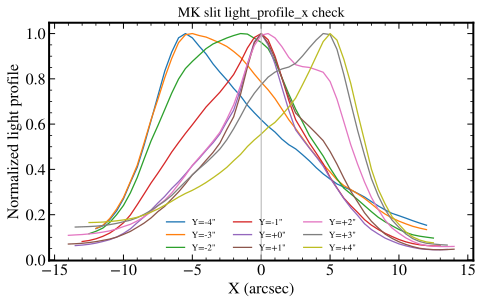

In [54]:
# =========================================================
# 6. Plot/check each slit light profile
# =========================================================
def plot_mk_light_profiles(mk_obs):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for ent in mk_obs["slits"]:
        x = np.asarray(ent["x_profile_arcsec"], dtype=float)
        lp = np.asarray(ent["light_profile_x"], dtype=float)
        if np.nanmax(lp) > 0:
            yplot = lp / np.nanmax(lp)
        else:
            yplot = lp
        ax.plot(x, yplot, lw=1.3, label=f"Y={ent['y_offset_arcsec']:+.0f}\"")
    ax.axvline(0.0, color="0.7", lw=1.0)
    ax.set_xlabel("X (arcsec)")
    ax.set_ylabel("Normalized light profile")
    ax.set_title("MK slit light_profile_x check")
    ax.legend(ncol=3, fontsize=9, frameon=False)
    ax.tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    return fig, ax

fig_lp, ax_lp = plot_mk_light_profiles(mk_obs)
plt.show()

[WARNING]: In the future `np.bool` will be defined as the corresponding NumPy scalar. (FutureWarning)
[WARNING]: In the future `np.object` will be defined as the corresponding NumPy scalar. (FutureWarning)
[WARNING]: In the future `np.str` will be defined as the corresponding NumPy scalar. (FutureWarning)


NumPy compatibility aliases patched.
mangadap version: 3.1.2
package dir: /home/jinelfy/.conda/envs/python3.8/lib/python3.8/site-packages/mangadap
ini exists: True /home/jinelfy/.conda/envs/python3.8/lib/python3.8/site-packages/mangadap/config/bitmasks/spectral_template_bits.ini
TemplateLibrary import OK
--------------------------------------------------
Template library output path: None
Template library output file: None


[WARNING]: Resampling results in resolution below the two pixel limit! (UserWarning)


Found 42 MILESHC templates
Maximum number of wavelength channels: 4300
Attempting to build raw data ...
... done
Matching sampling ... 
... done
After resampling (target): 0.00010000000000021103
After resampling (calculated): 0.00010000000000021084
--------------------------------------------------
 Best Fit:       Vel     sigma
 comp.  0:        -8        93
chi2/DOF: 1305.; DOF: 2831; degree = 8; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 8/42


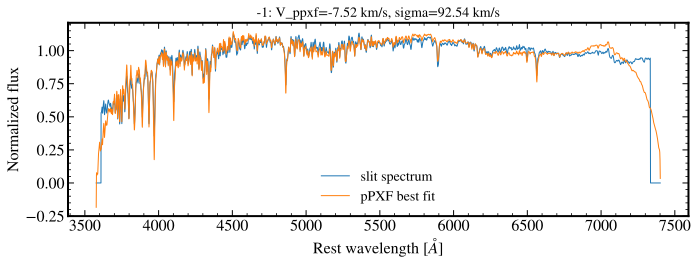

,slit_id,y_offset_arcsec,X_mean_arcsec,V_ppxf,V_losvd,V_err,V_err_formal,V_err_chi2,sigma,chi2,noise_source,lsf_status
0,-4,-4.0,-1.654760,-9.458275,-9.458275,0.413511,0.413511,9.905152,81.344636,573.782869,DRP-IVAR-propagated,matched-to-MaNGA-SRES
1,-3,-3.0,-1.606503,-9.721090,-9.721090,0.334375,0.334375,10.073893,85.198743,907.669680,DRP-IVAR-propagated,matched-to-MaNGA-SRES
2,-2,-2.0,-1.353110,-9.293073,-9.293073,0.292654,0.292654,10.402457,89.640252,1263.464960,DRP-IVAR-propagated,matched-to-MaNGA-SRES
3,-1,-1.0,-0.941407,-7.522697,-7.522697,0.297673,0.297673,10.754531,92.539475,1305.283899,DRP-IVAR-propagated,matched-to-MaNGA-SRES
4,0,0.0,-0.463289,-3.903421,-3.903421,0.316314,0.316314,11.093853,94.259575,1230.062934,DRP-IVAR-propagated,matched-to-MaNGA-SRES
5,1,1.0,-0.002292,0.033933,0.033933,0.316245,0.316245,11.330758,95.911975,1283.718072,DRP-IVAR-propagated,matched-to-MaNGA-SRES
6,2,2.0,0.466118,5.704793,5.704793,0.301186,0.301186,11.165278,94.975861,1374.263102,DRP-IVAR-propagated,matched-to-MaNGA-SRES
7,3,3.0,0.927856,11.168254,11.168254,0.320286,0.320286,10.866206,88.929448,1151.014089,DRP-IVAR-propagated,matched-to-MaNGA-SRES
8,4,4.0,1.342941,15.637545,15.637545,0.395108,0.395108,10.528958,81.528338,710.132743,DRP-IVAR-propagated,matched-to-MaNGA-SRES


In [55]:
# ---------------------------------------------------------
# Compatibility patch for old packages that still use np.int  *Old version
# ---------------------------------------------------------
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "bool"):
    np.bool = bool
if not hasattr(np, "object"):
    np.object = object
if not hasattr(np, "str"):
    np.str = str
if not hasattr(np, "complex"):
    np.complex = complex

print("NumPy compatibility aliases patched.")
from pathlib import Path
import mangadap
from scipy.ndimage import gaussian_filter1d

print("mangadap version:", mangadap.__version__)

pkg_dir = Path(mangadap.__file__).resolve().parent
ini = pkg_dir / "config" / "bitmasks" / "spectral_template_bits.ini"

print("package dir:", pkg_dir)
print("ini exists:", ini.exists(), ini)

from mangadap.proc.templatelibrary import TemplateLibrary
print("TemplateLibrary import OK")

# =========================================================
# 7. pPXF: moments=2, degree=8, mdegree=0; V_losvd = V_ppxf
#    Upgrades in this version:
#      (1) noise is propagated from the DRP IVAR cube through recast + slit collapse;
#      (2) MILESHC templates are matched to the MaNGA slit LSF before pPXF.
# =========================================================
PPXF_RESCALE_ERRORS_BY_CHI2 = False   # True gives the previous conservative pp.error*sqrt(chi2) convention.
MILESHC_FWHM_A = 2.50                 # Nominal MILES/MILESHC FWHM in Angstrom; adjust if your library metadata differs.


def robust_sigma(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if y.size < 10:
        return 1.0
    med = np.nanmedian(y)
    sig = 1.4826 * np.nanmedian(np.abs(y - med))
    return sig if np.isfinite(sig) and sig > 0 else 1.0


def is_log_sampled(lam, rtol=1e-4):
    lam = np.asarray(lam, dtype=float)
    lam = lam[np.isfinite(lam) & (lam > 0)]
    if lam.size < 10:
        return False
    dlog = np.diff(np.log(lam))
    return np.nanstd(dlog) <= rtol * np.nanmedian(np.abs(dlog))


def prepare_log_spectrum(lam_obs, flux, ivar=None, z=0.0):
    """Prepare a rest-frame log-lambda spectrum and its propagated noise."""
    lam_rest = np.asarray(lam_obs, dtype=float) / (1.0 + float(z))
    flux = np.asarray(flux, dtype=float)
    good = np.isfinite(lam_rest) & np.isfinite(flux) & (lam_rest > 0)

    var = None
    if ivar is not None:
        ivar = np.asarray(ivar, dtype=float)
        var = np.full_like(ivar, np.nan, dtype=float)
        ok = np.isfinite(ivar) & (ivar > 0)
        var[ok] = 1.0 / ivar[ok]
        good &= np.isfinite(var) & (var > 0)

    lam_rest = lam_rest[good]
    flux = flux[good]
    if var is not None:
        var = var[good]

    srt = np.argsort(lam_rest)
    lam_rest, flux = lam_rest[srt], flux[srt]
    if var is not None:
        var = var[srt]

    if is_log_sampled(lam_rest):
        lam_fit = lam_rest.copy()
        galaxy = flux.copy()
        velscale = C_KMS * np.median(np.diff(np.log(lam_fit)))
        if var is None:
            noise = np.full_like(galaxy, robust_sigma(galaxy))
            noise_source = "robust-constant"
        else:
            noise = np.sqrt(var)
            noise_source = "DRP-IVAR-propagated"
    else:
        galaxy, logLam, velscale = util.log_rebin([lam_rest[0], lam_rest[-1]], flux)
        lam_fit = np.exp(logLam)
        if var is None:
            noise = np.full_like(galaxy, robust_sigma(galaxy))
            noise_source = "robust-constant"
        else:
            # Approximate variance rebinning onto the same log-lambda grid.
            var_log, _, _ = util.log_rebin([lam_rest[0], lam_rest[-1]], var)
            noise = np.sqrt(np.abs(var_log))
            noise_source = "DRP-IVAR-propagated"

    bad_noise = ~np.isfinite(noise) | (noise <= 0)
    if np.any(bad_noise):
        fallback = robust_sigma(galaxy)
        noise[bad_noise] = fallback
    dlog10 = np.median(np.diff(np.log10(lam_fit)))
    return lam_fit, galaxy, noise, velscale, dlog10, noise_source


_TEMPLATE_CACHE = {}

def get_mileshc_templates(dlog10):
    key = round(float(dlog10), 8)
    if key in _TEMPLATE_CACHE:
        return _TEMPLATE_CACHE[key]
    tpl = TemplateLibrary(
        "MILESHC",
        velscale_ratio=1,
        spectral_step=float(dlog10),
        log=True,
        hardcopy=False,
    )
    tpl_wave = np.asarray(tpl["WAVE"].data, dtype=float)
    tpl_flux = np.asarray(tpl["FLUX"].data, dtype=float)
    if tpl_flux.ndim == 1:
        tpl_flux = tpl_flux[None, :]
    med = np.nanmedian(tpl_flux, axis=1)
    med[~np.isfinite(med) | (med == 0)] = 1.0
    tpl_flux = (tpl_flux.T / med).T
    _TEMPLATE_CACHE[key] = (tpl_wave, tpl_flux)
    return tpl_wave, tpl_flux


def interp_sres_to_lam_fit(wave_obs, sres1d, z, lam_fit):
    """Interpolate observed-frame MaNGA R(lambda) to the rest-frame lam_fit grid."""
    if sres1d is None:
        return None
    wave_obs = np.asarray(wave_obs, dtype=float)
    sres1d = np.asarray(sres1d, dtype=float)
    if sres1d.ndim != 1 or sres1d.size != wave_obs.size:
        return None
    lam_sres_rest = wave_obs / (1.0 + float(z))
    ok = np.isfinite(lam_sres_rest) & np.isfinite(sres1d) & (sres1d > 0)
    if np.count_nonzero(ok) < 10:
        return None
    return np.interp(lam_fit, lam_sres_rest[ok], sres1d[ok], left=np.nan, right=np.nan)


def gaussian_filter1d_variable_safe(arr, sigma_pix):
    """
    Smooth a 1-D spectrum with a variable Gaussian sigma in pixels.
    Use pPXF's utility if available; otherwise fall back to a constant median sigma.
    """
    arr = np.asarray(arr, dtype=float)
    sigma_pix = np.asarray(sigma_pix, dtype=float)
    sigma_pix = np.where(np.isfinite(sigma_pix) & (sigma_pix > 0), sigma_pix, 0.0)
    if np.nanmax(sigma_pix) <= 1e-6:
        return arr.copy()
    try:
        return util.gaussian_filter1d(arr, sigma_pix)
    except Exception:
        sig = float(np.nanmedian(sigma_pix[sigma_pix > 0]))
        if not np.isfinite(sig) or sig <= 0:
            return arr.copy()
        return gaussian_filter1d(arr, sig, mode="nearest")


def match_templates_to_manga_lsf(tpl_wave, tpl_flux, lam_fit, sres_fit,
                                template_fwhm_A=MILESHC_FWHM_A):
    """
    Match MILESHC templates to the slit-averaged MaNGA instrumental LSF.

    Parameters
    ----------
    tpl_wave : 1-D log-lambda template wavelength grid in Angstrom.
    tpl_flux : array, shape (n_templates, n_wave).
    lam_fit  : galaxy rest-frame wavelength grid.
    sres_fit : MaNGA R(lambda)=lambda/FWHM interpolated to lam_fit.

    Returns
    -------
    tpl_flux_matched : array with the same shape as tpl_flux.
    lsf_status : short text flag stored in the output table.
    """
    if sres_fit is None:
        return tpl_flux.copy(), "not-applied-no-sres"

    # Put the data LSF on the template grid, keeping only the overlap.
    sres_tpl = np.interp(tpl_wave, lam_fit, sres_fit, left=np.nan, right=np.nan)
    ok = np.isfinite(sres_tpl) & (sres_tpl > 0)
    if np.count_nonzero(ok) < 10:
        return tpl_flux.copy(), "not-applied-bad-sres"

    # Data and template Gaussian sigma in Angstrom.
    sigma_data_A = tpl_wave / sres_tpl / 2.354820045
    sigma_tpl_A = float(template_fwhm_A) / 2.354820045
    delta_sigma_A = np.sqrt(np.maximum(sigma_data_A**2 - sigma_tpl_A**2, 0.0))

    # Convert Angstrom sigma to pixels on the log-lambda template grid.
    dln = np.nanmedian(np.diff(np.log(tpl_wave)))
    sigma_pix = delta_sigma_A / (tpl_wave * dln)
    sigma_pix[~np.isfinite(sigma_pix)] = 0.0

    matched = np.empty_like(tpl_flux, dtype=float)
    for j in range(tpl_flux.shape[0]):
        matched[j] = gaussian_filter1d_variable_safe(tpl_flux[j], sigma_pix)
    return matched, "matched-to-MaNGA-SRES"


def stellar_goodpixels(lam_fit, tpl_wave, emline_half_width=12.0):
    mask = np.isfinite(lam_fit)
    mask &= (lam_fit >= tpl_wave.min() + 5.0)
    mask &= (lam_fit <= tpl_wave.max() - 5.0)
    em_lines = np.array([3726.03, 3728.82, 3868.76, 3889.05, 3967.47,
                         4101.73, 4340.47, 4861.33, 4958.92, 5006.84,
                         6300.30, 6363.78, 6548.05, 6562.80, 6583.45,
                         6716.44, 6730.82])
    for line in em_lines:
        mask &= np.abs(lam_fit - line) > emline_half_width
    return np.where(mask)[0]


def fit_one_slit_ppxf(flux1d, wave_obs, z, ivar1d=None, sres1d=None,
                      label="slit", moments=2, degree=8, mdegree=0, plot=False):
    lam_fit, galaxy, noise, velscale, dlog10, noise_source = prepare_log_spectrum(
        wave_obs, flux1d, ivar=ivar1d, z=z
    )
    tpl_wave, tpl_flux = get_mileshc_templates(dlog10)
    sres_fit = interp_sres_to_lam_fit(wave_obs, sres1d, z, lam_fit)
    tpl_flux, lsf_status = match_templates_to_manga_lsf(tpl_wave, tpl_flux, lam_fit, sres_fit)

    overlap = (lam_fit >= tpl_wave.min()) & (lam_fit <= tpl_wave.max())
    lam_fit, galaxy, noise = lam_fit[overlap], galaxy[overlap], noise[overlap]
    goodpixels = stellar_goodpixels(lam_fit, tpl_wave, emline_half_width=12.0)
    scale = np.nanmedian(galaxy[goodpixels])
    if not np.isfinite(scale) or scale == 0:
        scale = np.nanmedian(galaxy[np.isfinite(galaxy)])
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    galaxy = galaxy / scale
    noise = noise / abs(scale)

    dv = C_KMS * np.log(tpl_wave[0] / lam_fit[0])
    pp = ppxf(
        tpl_flux.T,
        galaxy,
        noise,
        velscale,
        start=[0.0, 120.0],
        goodpixels=goodpixels,
        moments=moments,
        degree=degree,
        mdegree=mdegree,
        lam=lam_fit,
        vsyst=dv,
        clean=False,
        quiet=not plot,
    )
    sol = np.array(pp.sol, ndmin=1, dtype=float)
    err = np.array(getattr(pp, "error", np.full_like(sol, np.nan)), ndmin=1, dtype=float)
    v_formal = err[0] if err.size > 0 else np.nan
    sig_formal = err[1] if err.size > 1 else np.nan
    v_chi2 = v_formal * np.sqrt(pp.chi2) if np.isfinite(v_formal) else np.nan
    sig_chi2 = sig_formal * np.sqrt(pp.chi2) if np.isfinite(sig_formal) else np.nan
    v_use = v_chi2 if PPXF_RESCALE_ERRORS_BY_CHI2 else v_formal
    sig_use = sig_chi2 if PPXF_RESCALE_ERRORS_BY_CHI2 else sig_formal

    res = {
        "label": label,
        "V_ppxf": sol[0] if sol.size > 0 else np.nan,
        "sigma": sol[1] if sol.size > 1 else np.nan,
        "V_err": v_use,
        "sigma_err": sig_use,
        "V_err_formal": v_formal,
        "V_err_chi2": v_chi2,
        "sigma_err_formal": sig_formal,
        "sigma_err_chi2": sig_chi2,
        "chi2": pp.chi2,
        "noise_source": noise_source,
        "lsf_status": lsf_status,
        "pp": pp,
        "wave_rest": lam_fit,
        "galaxy_norm": galaxy,
        "noise_norm": noise,
        "bestfit_norm": pp.bestfit,
    }
    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(lam_fit, galaxy, lw=1.0, label="slit spectrum")
        plt.plot(lam_fit, pp.bestfit, lw=1.0, label="pPXF best fit")
        plt.xlabel(r"Rest wavelength [$\AA$]")
        plt.ylabel("Normalized flux")
        plt.title(f"{label}: V_ppxf={res['V_ppxf']:.2f} km/s, sigma={res['sigma']:.2f} km/s")
        plt.legend(frameon=False)
        plt.tight_layout()
        plt.show()
    return res


def fit_all_mk_slits_ppxf(mk_obs, z, moments=2, degree=8, mdegree=0, plot_example=True):
    rows, results = [], []
    for i, ent in enumerate(mk_obs["slit_spectra"]):
        fit = fit_one_slit_ppxf(
            flux1d=ent["flux1d"],
            wave_obs=mk_obs["wave_obs"],
            z=z,
            ivar1d=ent.get("ivar1d", None),
            sres1d=ent.get("sres1d", None),
            label=ent["label"],
            moments=moments,
            degree=degree,
            mdegree=mdegree,
            plot=(plot_example and i == len(mk_obs["slit_spectra"]) // 2-1),
        )
        fit.update({k: ent[k] for k in ["slit_id", "y_offset_arcsec", "X_mean_arcsec", "x_left_arcsec", "x_right_arcsec", "n_spaxels"]})
        fit["V_losvd"] = fit["V_ppxf"]  # strict moments=2 implementation: first LOSVD moment equals pPXF V.
        results.append(fit)
        rows.append({k: v for k, v in fit.items() if np.isscalar(v) or isinstance(v, str)})
    return pd.DataFrame(rows).sort_values("slit_id").reset_index(drop=True), results

mk_kin_tab, mk_kin_results = fit_all_mk_slits_ppxf(
    mk_obs=mk_obs,
    z=z,
    moments=2,
    degree=8,
    mdegree=0,
    plot_example=True,
)

display(mk_kin_tab[[
    "slit_id", "y_offset_arcsec", "X_mean_arcsec", "V_ppxf", "V_losvd",
    "V_err", "V_err_formal", "V_err_chi2", "sigma", "chi2", "noise_source", "lsf_status"
]])

MK fit summary:
  slope_kms_per_arcsec     = 8.49235
  slope_err_kms_per_arcsec = 0.109997
  Omega_p_arcsec           = 8.49235
  Omega_p_arcsec_err       = 0.109997
  Omega_p                  = 8.49235
  Omega_p_err              = 0.109997
  unit                     = km s^-1 arcsec^-1


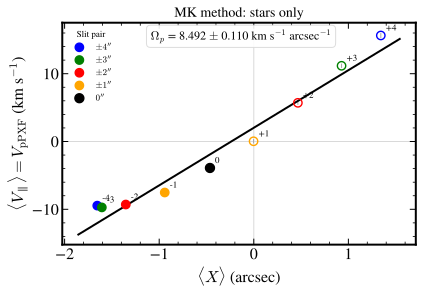

In [57]:
# =========================================================
# 8. Fit <V> vs <X>, convert slope to physical Omega_p, and plot
# =========================================================
def weighted_linear_fit(x, y, yerr=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    if yerr is not None:
        yerr = np.asarray(yerr, dtype=float)
        good &= np.isfinite(yerr) & (yerr > 0)
    x, y = x[good], y[good]
    if yerr is not None:
        yerr = yerr[good]
    if x.size < 2:
        return None
    A = np.vstack([x, np.ones_like(x)]).T
    if yerr is None or yerr.size != x.size:
        cov = np.linalg.inv(A.T @ A)
        pars = cov @ (A.T @ y)
    else:
        w = 1.0 / yerr**2
        Aw = A * np.sqrt(w)[:, None]
        yw = y * np.sqrt(w)
        cov = np.linalg.inv(Aw.T @ Aw)
        pars = cov @ (Aw.T @ yw)
    slope, intercept = pars
    return {
        "slope_kms_per_arcsec": float(slope),
        "intercept_kms": float(intercept),
        "slope_err_kms_per_arcsec": float(np.sqrt(cov[0, 0])), 
        "intercept_err_kms": float(np.sqrt(cov[1, 1])),
        "cov": cov,
        "n": int(x.size),
    }


def add_physical_omega(fit, maps=None, master_row=None, ellipticity=None):
    """
    Keep the MK fitted slope in the native angular unit.

    Here <X> is measured in arcsec and <V> in km/s, so the fitted slope has unit:
        km s^-1 arcsec^-1

    No distance conversion to kpc is applied.
    No inclination correction is applied.
    """
    fit = dict(fit)

    fit["Omega_p_arcsec"] = fit["slope_kms_per_arcsec"]
    fit["Omega_p_arcsec_err"] = fit["slope_err_kms_per_arcsec"]

    # Compatibility aliases for later cells.
    # Important: these are now in km/s/arcsec, NOT km/s/kpc.
    fit["Omega_p"] = fit["slope_kms_per_arcsec"]
    fit["Omega_p_err"] = fit["slope_err_kms_per_arcsec"] 

    return fit

mk_fit = weighted_linear_fit(   #在 weighted_linear_fit() 里，如果传入了 yerr，代码会做 weighted least squares: 每条 slit 的 pPXF 速度误差 V_err参与了linear fit 的加权，权重是1/sigma^2_{V,k,pPXF}
    x=mk_kin_tab["X_mean_arcsec"].to_numpy(float),
    y=mk_kin_tab["V_losvd"].to_numpy(float),
    yerr=mk_kin_tab["V_err"].to_numpy(float),
)
mk_fit = add_physical_omega(mk_fit, maps=maps, master_row=master_row, ellipticity=e_disk)

print("MK fit summary:")   #每次fit的斜率误差：slope_err_kms_per_arcsec 来自 weighted fit 的 covariance matrix：σ_{s,j}=\sqrt{C_{00}}​
for k in ["slope_kms_per_arcsec", "slope_err_kms_per_arcsec", "Omega_p_arcsec", "Omega_p_arcsec_err", "Omega_p", "Omega_p_err"]:
    print(f"  {k:24s} = {mk_fit[k]:.6g}")
print("  unit                     = km s^-1 arcsec^-1")


def _style_for_yabs(yabs):
    """Consistent style for different slit offsets.

    The absolute slit offset sets the color, so +Y and -Y from the
    same slit pair use the same color. Positive-Y points are open
    symbols; negative-Y points are filled symbols.
    """
    y = int(round(abs(float(yabs))))
    cmap = {1: "orange", 2: "red", 3: "green", 4: "blue"}
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    c = cmap.get(y, color_cycle[y % len(color_cycle)])
    return {
        "color": c,
        "label_pos": rf"$+{y}''$",
        "label_neg": rf"$-{y}''$",
        "label_sym": rf"$\pm {y}''$",
    }


def plot_mk_star_fit_physical(tab, fit, annotate_points=True, show_errorbar=True):
    fig, ax = plt.subplots(figsize=(6.2, 4.4))
    tab = tab.copy()
    tab["is_center"] = np.isclose(tab["y_offset_arcsec"], 0.0)

    legend_seen = set()
    for _, row in tab.iterrows():
        sid = int(row["slit_id"])
        yoff = float(row["y_offset_arcsec"])
        if np.isclose(yoff, 0.0):
            ec, fc, ms = "k", "k", 80
            legend_label = r"$0''$" if "center" not in legend_seen else None
            legend_seen.add("center")
        else:
            st = _style_for_yabs(yoff)
            ec = st["color"]
            # Use the same color for the ± pair; keep sign information by fill style.
            fc = st["color"] if yoff < 0 else "none"
            ms = 70
            key = int(round(abs(yoff)))
            legend_label = st["label_sym"] if key not in legend_seen else None
            legend_seen.add(key)

        ax.scatter(
            row["X_mean_arcsec"], row["V_losvd"],
            s=ms, edgecolor=ec, facecolor=fc, linewidth=1.4,
            label=legend_label, zorder=3,
        )
        if annotate_points:
            label = f"{sid:+d}" if sid != 0 else "0"
            ax.annotate(label, (row["X_mean_arcsec"], row["V_losvd"]), xytext=(5, 5),
                        textcoords="offset points", fontsize=9)

    if show_errorbar and np.any(np.isfinite(tab["V_err"])):
        # Keep error bars neutral so the absolute-Y color sequence is carried by the points.
        ax.errorbar(tab["X_mean_arcsec"], tab["V_losvd"], yerr=tab["V_err"], fmt="none",
                    ecolor="0.65", elinewidth=1.0, capsize=0, zorder=1)

    x = tab["X_mean_arcsec"].to_numpy(float)
    x = x[np.isfinite(x)]
    xline = np.linspace(np.nanmin(x) - 0.2, np.nanmax(x) + 0.2, 300)
    yline = fit["slope_kms_per_arcsec"] * xline + fit["intercept_kms"]
    ax.plot(xline, yline, "k-", lw=2.0, zorder=2)

    label = (
        rf"$\Omega_p$ = {fit['slope_kms_per_arcsec']:.3f} $\pm$ {fit['slope_err_kms_per_arcsec']:.3f} km s$^{{-1}}$ arcsec$^{{-1}}$"
        # rf"$\Omega_p \sin i$ = {fit['Omega_p_sin_i']:.2f} $\pm$ {fit['Omega_p_sin_i_err']:.2f} km s$^{{-1}}$ kpc$^{{-1}}$" "\n"
        # rf"$\Omega_p$ = {fit['Omega_p']:.2f} $\pm$ {fit['Omega_p_err']:.2f} km s$^{{-1}}$ kpc$^{{-1}}$"
    )
    ax.text(0.25, 0.97, label, transform=ax.transAxes, ha="left", va="top", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.85", alpha=0.9))

    ax.axhline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.axvline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.set_xlabel(r"$\langle X \rangle$ (arcsec)")
    ax.set_ylabel(r"$\langle V_{\parallel} \rangle = V_{\rm pPXF}$ (km s$^{-1}$)")
    ax.set_title("MK method: stars only")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(title="Slit pair", fontsize=9, title_fontsize=9, frameon=False, loc="best")
    plt.tight_layout()
    return fig, ax

fig_mk, ax_mk = plot_mk_star_fit_physical(mk_kin_tab, mk_fit)
plt.show()

In [23]:
# =========================================================
# 9. Save tables and lightweight outputs
# =========================================================
outdir = Path("./saved_outputs")
outdir.mkdir(parents=True, exist_ok=True)

mk_kin_tab.to_csv(outdir / f"{galaxy_id}_OP_MK_slit_table.csv", index=False)
with open(outdir / f"{galaxy_id}_OP_MK_fit_summary.pkl", "wb") as f:
    pickle.dump({"mk_fit": mk_fit, "mk_obs_meta": mk_obs["meta"]}, f)
fig_lp.savefig(outdir / f"{galaxy_id}_OP_MK_light_profiles.png", dpi=300, bbox_inches="tight")
fig_mk.savefig(outdir / f"{galaxy_id}_OP_MK_fit_physical.png", dpi=300, bbox_inches="tight")

print("Saved OP_MK outputs to", outdir.resolve())

Saved OP_MK outputs to /home/jinelfy/TW_external/saved_outputs



# MK-method Monte Carlo uncertainty from PA\_disk,kin samples

This section follows the MC prescription used in the paper for the MK workflow:

1. draw/use 100 realisations of `PA_disk,kin`;
2. recast the stellar continuum cube, propagated variance cube, and LSF/SRES cube for every PA realisation;
3. build the same explicit pseudo-slits on the newly recast grid;
4. fit each 1D slit spectrum with pPXF;
5. fit the MK `<V>`--`<X>` relation for each realisation;
6. adopt the mean and 1σ scatter over the MC measurements.

For this MK implementation, the centre and systemic velocity are intentionally kept fixed:
`Xc_best = 0.000 arcsec`, `Yc_best = 0.000 arcsec`, `Vsys_best = 0.000 km/s`.


In [23]:
# =========================================================
# 0. Basic setup
# =========================================================
%config InlineBackend.figure_formats = ['svg']
import json, pickle, gzip
from marvin.tools.cube import Cube
C_KMS = 299792.458

CACHE_ROOT = Path("/home/jinelfy/TW_external/intermediate_cache")
ELLIPSE_DIR = CACHE_ROOT / "ellipse"
PA_DIR = CACHE_ROOT / "pa_disk"
MASTER_CSV = CACHE_ROOT / "master_table.csv"
TW_CENTER_DIR = CACHE_ROOT / "tw_center"
TW_CENTER_DIR.mkdir(parents=True, exist_ok=True)

def get_float_from_master(row, colname, default=np.nan):
    if colname not in row.index:
        return default
    val = row[colname]
    return float(val) if pd.notna(val) else default 

def load_json(path):
    with open(Path(path), "r", encoding="utf-8") as f:
        return json.load(f)

def load_ellipse_result(plateifu, outdir=ELLIPSE_DIR):
    infile = Path(outdir) / f"ellipse_{plateifu}.json"
    with open(infile, "r", encoding="utf-8") as f:
        return json.load(f)
    
def signed_axis_diff_deg(pa1, pa2):
    d = (float(pa1) - float(pa2)) % 180.0
    if d > 90.0:
        d -= 180.0
    return d
galaxy_id = "8312-12702"
pixscale = 0.5  # arcsec / pixel for MaNGA reconstructed cube
slit_width_arcsec = 2.0
slit_centers_arcsec = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

master_table = pd.read_csv(MASTER_CSV)
master_row = master_table[master_table["plateifu"].astype(str) == galaxy_id].iloc[0]

Vsys_ref = 0 #get_float_from_master(master_row, "Vsys_ref")
PA_disk_kin = get_float_from_master(master_row, "PA_disk_kin_mode_deg_0_180") - 90.0
Xc_best_arcsec = 0 #get_float_from_master(master_row, "Xc_best_arcsec")
Yc_best_arcsec = 0 #get_float_from_master(master_row, "Yc_best_arcsec")
Vsys_best = 0 #get_float_from_master(master_row, "Vsys_best")

ellipse_payload = load_ellipse_result(galaxy_id)
PA_bar = float(ellipse_payload["PA_bar_deg_0_180"])
a_max = float(ellipse_payload["a_max_arcsec"])

# Prefer e_disk already stored in the master table. Otherwise use values from the ellipse payload if present.
e_disk = get_float_from_master(master_row, "e_disk", default=np.nan)
if not np.isfinite(e_disk):
    for key in ["e_disk", "ellipticity", "ellipticity_disk"]:
        if key in ellipse_payload:
            e_disk = float(ellipse_payload[key])
            break

phi_bar_disk = signed_axis_diff_deg(PA_bar, PA_disk_kin)
bar_half_width_arcsec = a_max * abs(np.sin(np.deg2rad(phi_bar_disk)))

print(f"galaxy_id = {galaxy_id}")
print(f"PA_disk_kin = {PA_disk_kin:.3f} deg")
print(f"Xc_best, Yc_best = {Xc_best_arcsec:.3f}, {Yc_best_arcsec:.3f} arcsec")
print(f"Vsys_best = {Vsys_best:.3f} km/s")
print(f"PA_bar = {PA_bar:.3f} deg, a_max = {a_max:.3f} arcsec")
print(f"bar_half_width = {bar_half_width_arcsec:.3f} arcsec")

galaxy_id = 8312-12702
PA_disk_kin = 6.000 deg
Xc_best, Yc_best = 0.000, 0.000 arcsec
Vsys_best = 0.000 km/s
PA_bar = 120.279 deg, a_max = 6.494 arcsec
bar_half_width = 5.920 arcsec


In [24]:

# =========================================================
# 10. Load PA_disk,kin Monte-Carlo samples from PA_DISK.ipynb
# =========================================================
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

mc_outdir = Path("./saved_outputs/MK_MC")
mc_outdir.mkdir(parents=True, exist_ok=True)

pa_mc_dir = Path("./pa_mc_outputs")
pa_csv_candidates = [
    pa_mc_dir / f"PA_disk_kin_MC_star_{galaxy_id}.csv",
    pa_mc_dir / "PA_disk_kin_MC_star.csv",
]
pa_npz_candidates = [
    pa_mc_dir / f"PA_disk_kin_MC_star_{galaxy_id}.npz",
    pa_mc_dir / "PA_disk_kin_MC_star.npz",
]

def load_pa_disk_kin_mc_samples(pa_csv_candidates, pa_npz_candidates):
    """Load PA_disk,kin MC samples generated in PA_DISK.ipynb."""
    for path in pa_csv_candidates:
        if path.exists():
            df = pd.read_csv(path)
            if "PA_disk_kin_MC_deg" not in df.columns:
                raise KeyError(f"{path} does not contain column 'PA_disk_kin_MC_deg'.")
            return df["PA_disk_kin_MC_deg"].to_numpy(float), df, path

    for path in pa_npz_candidates:
        if path.exists():
            dat = np.load(path)
            pa = np.asarray(dat["PA_disk_kin_MC_deg"], dtype=float)
            df = pd.DataFrame({
                "sample_id": np.arange(len(pa), dtype=int),
                "PA_disk_kin_MC_deg": pa,
            })
            return pa, df, path

    msg = "Could not find PA_disk,kin MC samples. Searched:\n"
    msg += "\n".join(str(p) for p in list(pa_csv_candidates) + list(pa_npz_candidates))
    raise FileNotFoundError(msg)

pa_disk_kin_mc_deg, pa_disk_kin_mc_df, pa_sample_file = load_pa_disk_kin_mc_samples(
    pa_csv_candidates=pa_csv_candidates,
    pa_npz_candidates=pa_npz_candidates,
)

print(f"[Loaded] {pa_sample_file}")
print(f"N(PA samples) = {len(pa_disk_kin_mc_deg)}")
print(
    f"PA_disk,kin MC mean/std = "
    f"{np.nanmean(pa_disk_kin_mc_deg):.6f} / {np.nanstd(pa_disk_kin_mc_deg, ddof=1):.6f} deg"
)

# IMPORTANT:
# In TW_OP_MK_once.ipynb the recast angle was defined as
#     PA_disk_kin = master PA_disk_kin_mode_deg_0_180 - 90.0
# Keep the same convention here, unless you deliberately change the convention upstream.
# PA_MC_VALUES_ARE_SKY_MAJOR_AXIS = True
pa_recast_mc_deg = pa_disk_kin_mc_deg #- 90.0 if PA_MC_VALUES_ARE_SKY_MAJOR_AXIS else pa_disk_kin_mc_deg

# Fixed MK centering / systemic velocity requested for the MC experiment.
Xc_best = 0.0
Yc_best = 0.0
Vsys_best = 0.0

print(f"Fixed MK centre: Xc_best = {Xc_best:.3f} arcsec, Yc_best = {Yc_best:.3f} arcsec")
print(f"Fixed MK systemic velocity offset: Vsys_best = {Vsys_best:.3f} km/s")


[Loaded] pa_mc_outputs/PA_disk_kin_MC_star.csv
N(PA samples) = 100
PA_disk,kin MC mean/std = 5.228397 / 1.506886 deg
Fixed MK centre: Xc_best = 0.000 arcsec, Yc_best = 0.000 arcsec
Fixed MK systemic velocity offset: Vsys_best = 0.000 km/s


In [25]:

# =========================================================
# 11. MK-MC helpers
# =========================================================

# Convert native DRP IVAR cube to native variance cube once.
# Each MC realisation then recasts this variance cube, so the pPXF noise/error
# spectrum is PA-specific rather than copied from the nominal recast.
flux_var_native = np.full_like(flux_ivar_native, np.nan, dtype=float)
good_ivar = np.isfinite(flux_ivar_native) & (flux_ivar_native > 0)
flux_var_native[good_ivar] = 1.0 / flux_ivar_native[good_ivar]

def build_recasted_mk_inputs_for_pa(
    pa_recast_deg,
    min_valid_frac=0.999,
    preserve_sum=True,
    verbose=False,
):
    """
    Recast the stellar continuum cube, propagated variance cube, and SRES/LSF cube
    for one PA_disk,kin MC realisation.

    This intentionally does NOT reuse the cached nominal-PA recast mask from fig4_out.pkl,
    because the mask/noise geometry should follow the MC recast angle.
    """
    stellar_cube_rec, flux_var_rec = recast_spectral_cube_with_variance(
        cube3d=stellar_model_cube_native,
        var3d=flux_var_native,
        pa_disk_deg=float(pa_recast_deg),
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixscale,
        min_valid_frac=min_valid_frac,
        preserve_sum=preserve_sum,
        verbose=verbose,
    )

    sres_rec = recast_spectral_resolution(
        sres=sres_native,
        pa_disk_deg=float(pa_recast_deg),
        x_arcsec=x_arcsec,
        y_arcsec=y_arcsec,
        pixel_scale=pixscale,
        min_valid_frac=min_valid_frac,
        verbose=verbose,
    )

    # Same stellar-continuum SB construction as the nominal MK notebook.
    mask_wave = (wave_rest >= 5600.0) & (wave_rest <= 6750.0)
    dlam = np.nanmedian(np.diff(wave_rest[mask_wave]))
    stellar_sb_rec = np.nansum(stellar_cube_rec[mask_wave, :, :], axis=0) * dlam

    # MC-specific validity mask.  The variance cube is recast above, so the
    # propagated error map follows the PA realisation.
    var_ok_2d = np.any(np.isfinite(flux_var_rec) & (flux_var_rec > 0), axis=0)
    geometry_mask_rec = np.isfinite(stellar_sb_rec) & (stellar_sb_rec > 0)
    display_mask_rec = geometry_mask_rec & var_ok_2d

    return {
        "stellar_cube_recast": stellar_cube_rec,
        "stellar_var_recast": flux_var_rec,
        "sres_recast": sres_rec,
        "stellar_sb_recast": stellar_sb_rec,
        "stellar_sigma_recast": stellar_sb_rec,  # compatibility alias
        "display_mask_star": display_mask_rec,
        "geometry_mask_recast": geometry_mask_rec,
    }


def run_one_mk_mc_realisation(
    sample_id,
    pa_disk_kin_sample_deg,
    pa_recast_deg,
    plot_example=False,
    verbose=False,
):
    """
    Run the full MK measurement for one PA_disk,kin MC realisation.

    Centre and Vsys are fixed to the requested MK values:
    Xc = 0 arcsec, Yc = 0 arcsec, Vsys = 0 km/s.
    """
    rec = build_recasted_mk_inputs_for_pa(
        pa_recast_deg=pa_recast_deg,
        min_valid_frac=0.999,
        preserve_sum=True,
        verbose=verbose,
    )

    mk_obs_i = build_mk_slit_1d_from_recast_cube(
        cube_recast=rec["stellar_cube_recast"],
        wave_obs=wave_obs,
        stellar_sb_recast=rec["stellar_sb_recast"],
        valid_mask=rec["display_mask_star"],
        x_axis=x_axis_mk,
        y_axis=y_axis_mk,
        slit_centers_arcsec=slit_centers_arcsec,
        var_recast=rec["stellar_var_recast"],
        sres_recast=rec["sres_recast"],
        slit_width_arcsec=slit_width_arcsec,
        x_center_arcsec=Xc_best,
        combine="sum",
        verbose=verbose,
    )

    tab_i, ppxf_results_i = fit_all_mk_slits_ppxf(  #对每条 slit 的 1D spectrum 做 pPXF：
        mk_obs=mk_obs_i,
        z=z,
        moments=2,
        degree=8,
        mdegree=0,
        plot_example=plot_example,
    )

    # Remove any systemic velocity offset if a non-zero value is ever supplied.
    # For the requested run Vsys_best = 0.0, so this is a no-op.
    tab_i = tab_i.copy()
    tab_i["V_losvd"] = tab_i["V_losvd"].astype(float) - float(Vsys_best)
    if "V_ppxf" in tab_i.columns:
        tab_i["V_ppxf"] = tab_i["V_ppxf"].astype(float) - float(Vsys_best) #每条 slit 的速度采用拟合得到的V_ppxf

    fit_i = weighted_linear_fit(              #每一次MC的每一组 slit 点被拿去做线性拟合，
        x=tab_i["X_mean_arcsec"].to_numpy(float),
        y=tab_i["V_losvd"].to_numpy(float),  
        yerr=tab_i["V_err"].to_numpy(float),
    )
    fit_i = add_physical_omega(fit_i, maps=maps, master_row=master_row, ellipticity=e_disk)

    # Attach MC bookkeeping.
    tab_i.insert(0, "sample_id", int(sample_id))
    tab_i.insert(1, "PA_disk_kin_MC_deg", float(pa_disk_kin_sample_deg))
    tab_i.insert(2, "PA_recast_deg", float(pa_recast_deg))

    fit_row = {
        "sample_id": int(sample_id),
        "PA_disk_kin_MC_deg": float(pa_disk_kin_sample_deg),
        "PA_recast_deg": float(pa_recast_deg),
        **{k: v for k, v in fit_i.items() if np.isscalar(v)},
    }

    return tab_i, fit_row, fit_i, mk_obs_i



[MK MC 001/100] sample_id=0, PA_disk,kin=6.486922 deg, PA_recast=6.486922 deg


 Best Fit:       Vel     sigma
 comp.  0:        -7        93
chi2/DOF: 1291.; DOF: 2831; degree = 8; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 8/42


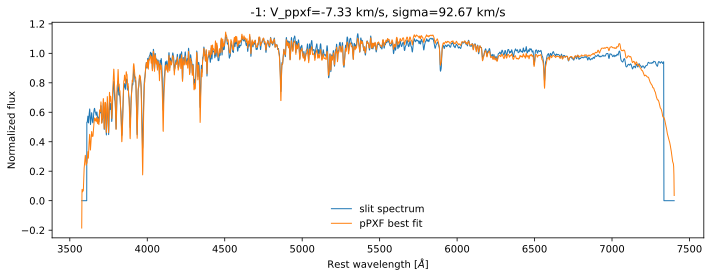


[MK MC 002/100] sample_id=1, PA_disk,kin=6.631835 deg, PA_recast=6.631835 deg

[MK MC 003/100] sample_id=2, PA_disk,kin=4.202561 deg, PA_recast=4.202561 deg

[MK MC 004/100] sample_id=3, PA_disk,kin=5.630967 deg, PA_recast=5.630967 deg

[MK MC 005/100] sample_id=4, PA_disk,kin=3.238490 deg, PA_recast=3.238490 deg

[MK MC 006/100] sample_id=5, PA_disk,kin=4.293244 deg, PA_recast=4.293244 deg

[MK MC 007/100] sample_id=6, PA_disk,kin=5.939647 deg, PA_recast=5.939647 deg

[MK MC 008/100] sample_id=7, PA_disk,kin=6.458291 deg, PA_recast=6.458291 deg

[MK MC 009/100] sample_id=8, PA_disk,kin=7.445267 deg, PA_recast=7.445267 deg

[MK MC 010/100] sample_id=9, PA_disk,kin=4.343706 deg, PA_recast=4.343706 deg

[MK MC 011/100] sample_id=10, PA_disk,kin=6.290184 deg, PA_recast=6.290184 deg

[MK MC 012/100] sample_id=11, PA_disk,kin=8.107043 deg, PA_recast=8.107043 deg

[MK MC 013/100] sample_id=12, PA_disk,kin=6.457732 deg, PA_recast=6.457732 deg

[MK MC 014/100] sample_id=13, PA_disk,kin=2.5157

,sample_id,PA_disk_kin_MC_deg,PA_recast_deg,slope_kms_per_arcsec,intercept_kms,slope_err_kms_per_arcsec,intercept_err_kms,n,inclination_deg,kpc_per_arcsec,Omega_p_sin_i,Omega_p_sin_i_err,Omega_p,Omega_p_err
0,0,6.486922,6.486922,7.904214,1.718901,0.118754,0.121357,9,49.046429,0.660842,11.960826,0.179702,15.837100,0.237940
1,1,6.631835,6.631835,7.778331,1.658864,0.119042,0.121394,9,49.046429,0.660842,11.770338,0.180138,15.584878,0.238517
2,2,4.202561,4.202561,10.015034,2.793768,0.114800,0.119647,9,49.046429,0.660842,15.154964,0.173718,20.066396,0.230016
3,3,5.630967,5.630967,8.685821,2.160509,0.115374,0.118882,9,49.046429,0.660842,13.143571,0.174587,17.403150,0.231167
4,4,3.238490,3.238490,10.974319,3.200705,0.117485,0.120764,9,49.046429,0.660842,16.606576,0.177781,21.988447,0.235396


In [16]:

# =========================================================
# 12. Run the 100-realisation MK Monte Carlo
# =========================================================

N_MK_MC = len(pa_recast_mc_deg)   # expected: 100
SAVE_EVERY = 1                    # save after every realisation for safe long runs
PLOT_FIRST_PPXF_EXAMPLE = True

all_slit_tables = []
all_fit_rows = []
failed_rows = []

for j, (pa_sky, pa_rec) in enumerate(zip(pa_disk_kin_mc_deg[:N_MK_MC], pa_recast_mc_deg[:N_MK_MC])):
    sample_id = int(pa_disk_kin_mc_df["sample_id"].iloc[j]) if "sample_id" in pa_disk_kin_mc_df.columns else int(j)
    print(
        f"\n[MK MC {j+1:03d}/{N_MK_MC:03d}] "
        f"sample_id={sample_id}, PA_disk,kin={pa_sky:.6f} deg, PA_recast={pa_rec:.6f} deg"
    )

    try:
        tab_i, fit_row_i, fit_i, mk_obs_i = run_one_mk_mc_realisation(
            sample_id=sample_id,
            pa_disk_kin_sample_deg=pa_sky,
            pa_recast_deg=pa_rec,
            plot_example=(PLOT_FIRST_PPXF_EXAMPLE and j == 0),
            verbose=False,
        )
        all_slit_tables.append(tab_i)
        all_fit_rows.append(fit_row_i)

    except Exception as exc:
        print(f"  [FAILED] sample_id={sample_id}: {repr(exc)}")
        failed_rows.append({
            "sample_id": sample_id,
            "PA_disk_kin_MC_deg": float(pa_sky),
            "PA_recast_deg": float(pa_rec),
            "error": repr(exc),
        })

    if ((j + 1) % SAVE_EVERY == 0) and len(all_fit_rows) > 0:
        pd.concat(all_slit_tables, ignore_index=True).to_csv(
            mc_outdir / f"{galaxy_id}_OP_MK_MC_slit_measurements_partial.csv",
            index=False,
        )
        pd.DataFrame(all_fit_rows).to_csv(
            mc_outdir / f"{galaxy_id}_OP_MK_MC_fit_measurements_partial.csv",
            index=False,
        )
        if len(failed_rows) > 0:
            pd.DataFrame(failed_rows).to_csv(
                mc_outdir / f"{galaxy_id}_OP_MK_MC_failed_partial.csv",
                index=False,
            )

mk_mc_slit_df = pd.concat(all_slit_tables, ignore_index=True) if len(all_slit_tables) else pd.DataFrame()
mk_mc_fit_df = pd.DataFrame(all_fit_rows)
mk_mc_failed_df = pd.DataFrame(failed_rows)

mk_mc_slit_df.to_csv(mc_outdir / f"{galaxy_id}_OP_MK_MC_slit_measurements.csv", index=False)
mk_mc_fit_df.to_csv(mc_outdir / f"{galaxy_id}_OP_MK_MC_fit_measurements.csv", index=False)
if len(mk_mc_failed_df) > 0:
    mk_mc_failed_df.to_csv(mc_outdir / f"{galaxy_id}_OP_MK_MC_failed.csv", index=False)

print("\nSaved MK MC tables to:", mc_outdir.resolve())
print(f"Successful MC realisations: {len(mk_mc_fit_df)} / {N_MK_MC}")
print(f"Failed MC realisations:     {len(mk_mc_failed_df)}")
display(mk_mc_fit_df.head())


In [26]:
# =========================================================
# 12b. Reload saved MK Monte Carlo results
#     Run this cell instead of re-running Cell 12
# =========================================================

# Make sure mc_outdir and galaxy_id are already defined in previous cells.
mc_outdir = Path(mc_outdir)

def _pick_existing_mc_file(final_path, partial_path, label):
    """
    Prefer the final MC file if it exists and is non-empty.
    Otherwise fall back to the partial MC file.
    """
    final_path = Path(final_path)
    partial_path = Path(partial_path)

    candidates = []
    for path in [final_path, partial_path]:
        if path.exists() and path.stat().st_size > 0:
            candidates.append(path)

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Cannot find saved {label} file.\n"
            f"Checked:\n"
            f"  {final_path}\n"
            f"  {partial_path}\n"
            "Please run Cell 12 first, or check mc_outdir / galaxy_id."
        )

    # If both exist, use the final file. This is safest after a completed Cell 12 run.
    if final_path in candidates:
        return final_path

    return partial_path


# ---------- Define expected file paths ----------
mk_slit_final_file = mc_outdir / f"{galaxy_id}_OP_MK_MC_slit_measurements.csv"
mk_fit_final_file  = mc_outdir / f"{galaxy_id}_OP_MK_MC_fit_measurements.csv"
mk_fail_final_file = mc_outdir / f"{galaxy_id}_OP_MK_MC_failed.csv"

mk_slit_partial_file = mc_outdir / f"{galaxy_id}_OP_MK_MC_slit_measurements_partial.csv"
mk_fit_partial_file  = mc_outdir / f"{galaxy_id}_OP_MK_MC_fit_measurements_partial.csv"
mk_fail_partial_file = mc_outdir / f"{galaxy_id}_OP_MK_MC_failed_partial.csv"


# ---------- Reload slit-level and fit-level MC tables ----------
mk_slit_file_to_load = _pick_existing_mc_file(
    mk_slit_final_file,
    mk_slit_partial_file,
    label="MK MC slit measurements",
)

mk_fit_file_to_load = _pick_existing_mc_file(
    mk_fit_final_file,
    mk_fit_partial_file,
    label="MK MC fit measurements",
)

mk_mc_slit_df = pd.read_csv(mk_slit_file_to_load)
mk_mc_fit_df  = pd.read_csv(mk_fit_file_to_load)


# ---------- Reload failed table if available ----------
if mk_fail_final_file.exists() and mk_fail_final_file.stat().st_size > 0:
    mk_mc_failed_df = pd.read_csv(mk_fail_final_file)
elif mk_fail_partial_file.exists() and mk_fail_partial_file.stat().st_size > 0:
    mk_mc_failed_df = pd.read_csv(mk_fail_partial_file)
else:
    mk_mc_failed_df = pd.DataFrame()


# ---------- Optional: restore list-like variables used in Cell 12 ----------
# Cell 13 only needs mk_mc_slit_df, mk_mc_fit_df, and mk_mc_failed_df,
# but these are restored for compatibility with your Cell 12 variable names.
all_fit_rows = mk_mc_fit_df.to_dict("records")

if "sample_id" in mk_mc_slit_df.columns:
    all_slit_tables = [
        g.reset_index(drop=True)
        for _, g in mk_mc_slit_df.groupby("sample_id", sort=True)
    ]
else:
    all_slit_tables = [mk_mc_slit_df.copy()]

failed_rows = mk_mc_failed_df.to_dict("records")


# ---------- Basic consistency checks for Cell 13 ----------
required_slit_cols = [
    "slit_id",
    "y_offset_arcsec",
    "X_mean_arcsec",
    "V_losvd",
    "V_err",
]

missing_slit_cols = [c for c in required_slit_cols if c not in mk_mc_slit_df.columns]
if len(missing_slit_cols) > 0:
    raise KeyError(
        "The reloaded mk_mc_slit_df is missing columns required by Cell 13:\n"
        f"{missing_slit_cols}\n"
        f"Loaded file: {mk_slit_file_to_load}"
    )

if len(mk_mc_fit_df) == 0:
    raise RuntimeError(
        "The reloaded mk_mc_fit_df is empty. "
        "Cell 13 cannot build the MK MC summary from an empty fit table."
    )


# ---------- Reconstruct N_MK_MC if needed ----------
if "sample_id" in mk_mc_fit_df.columns:
    N_MK_MC_loaded = mk_mc_fit_df["sample_id"].nunique()
else:
    N_MK_MC_loaded = len(mk_mc_fit_df)

try:
    N_MK_MC
except NameError:
    N_MK_MC = N_MK_MC_loaded


print("Reloaded saved MK MC results:")
print(f"  slit table : {mk_slit_file_to_load}")
print(f"  fit table  : {mk_fit_file_to_load}")
print(f"  failed rows: {len(mk_mc_failed_df)}")
print()
print(f"Successful MC realisations loaded: {len(mk_mc_fit_df)}")
print(f"Unique sample_id loaded:           {N_MK_MC_loaded}")
print(f"N_MK_MC currently set to:           {N_MK_MC}")

display(mk_mc_fit_df.head())
display(mk_mc_slit_df.head())

Reloaded saved MK MC results:
  slit table : saved_outputs/MK_MC/8312-12702_OP_MK_MC_slit_measurements.csv
  fit table  : saved_outputs/MK_MC/8312-12702_OP_MK_MC_fit_measurements.csv
  failed rows: 0

Successful MC realisations loaded: 100
Unique sample_id loaded:           100
N_MK_MC currently set to:           100


,sample_id,PA_disk_kin_MC_deg,PA_recast_deg,slope_kms_per_arcsec,intercept_kms,slope_err_kms_per_arcsec,intercept_err_kms,n,inclination_deg,kpc_per_arcsec,Omega_p_sin_i,Omega_p_sin_i_err,Omega_p,Omega_p_err
0,0,6.486922,6.486922,7.904214,1.718901,0.118754,0.121357,9,49.046429,0.660842,11.960826,0.179702,15.837100,0.237940
1,1,6.631835,6.631835,7.778331,1.658864,0.119042,0.121394,9,49.046429,0.660842,11.770338,0.180138,15.584878,0.238517
2,2,4.202561,4.202561,10.015034,2.793768,0.114800,0.119647,9,49.046429,0.660842,15.154964,0.173718,20.066396,0.230016
3,3,5.630967,5.630967,8.685821,2.160509,0.115374,0.118882,9,49.046429,0.660842,13.143571,0.174587,17.403150,0.231167
4,4,3.238490,3.238490,10.974319,3.200705,0.117485,0.120764,9,49.046429,0.660842,16.606576,0.177781,21.988447,0.235396


,sample_id,PA_disk_kin_MC_deg,PA_recast_deg,label,V_ppxf,sigma,V_err,sigma_err,V_err_formal,V_err_chi2,...,chi2,noise_source,lsf_status,slit_id,y_offset_arcsec,X_mean_arcsec,x_left_arcsec,x_right_arcsec,n_spaxels,V_losvd
0,0,6.486922,6.486922,-4,-8.524427,81.817153,0.419393,0.604933,0.419393,9.890659,...,556.171532,DRP-IVAR-propagated,matched-to-MaNGA-SRES,-4,-4.0,-1.630779,-12.498664,12.501336,204,-8.524427
1,0,6.486922,6.486922,-3,-9.043940,85.972582,0.354169,0.496790,0.354169,10.111949,...,815.172453,DRP-IVAR-propagated,matched-to-MaNGA-SRES,-3,-3.0,-1.583716,-12.998664,13.001336,212,-9.043940
2,0,6.486922,6.486922,-2,-9.007431,89.934021,0.298652,0.410065,0.298652,10.438531,...,1221.654634,DRP-IVAR-propagated,matched-to-MaNGA-SRES,-2,-2.0,-1.361324,-12.998664,13.001336,212,-9.007431
3,0,6.486922,6.486922,-1,-7.332120,92.673264,0.299735,0.405859,0.299735,10.770573,...,1291.223365,DRP-IVAR-propagated,matched-to-MaNGA-SRES,-1,-1.0,-0.950456,-13.498664,13.501336,220,-7.332120
4,0,6.486922,6.486922,0,-3.661980,94.418246,0.320537,0.430411,0.320537,11.153731,...,1210.832273,DRP-IVAR-propagated,matched-to-MaNGA-SRES,0,0.0,-0.456752,-14.498664,14.501336,236,-3.661980


In [27]:
# =========================================================
# 12c. Force loaded MK MC results to use km/s/arcsec
# =========================================================

mk_mc_fit_df = mk_mc_fit_df.copy()

if "slope_kms_per_arcsec" not in mk_mc_fit_df.columns:
    raise KeyError("mk_mc_fit_df must contain 'slope_kms_per_arcsec'.")

if "slope_err_kms_per_arcsec" not in mk_mc_fit_df.columns:
    raise KeyError("mk_mc_fit_df must contain 'slope_err_kms_per_arcsec'.")

# Adopt the native MK fitted slope as the pattern speed.
# Unit: km s^-1 arcsec^-1.
mk_mc_fit_df["Omega_p_arcsec"] = mk_mc_fit_df["slope_kms_per_arcsec"]
mk_mc_fit_df["Omega_p_arcsec_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]

# Compatibility aliases for old plotting/summary code.
# These are now km/s/arcsec, not km/s/kpc.
mk_mc_fit_df["Omega_p"] = mk_mc_fit_df["slope_kms_per_arcsec"]
mk_mc_fit_df["Omega_p_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]

# Remove old physical-conversion columns if they exist, to avoid accidental use.
for col in [
    "Omega_p_sin_i",
    "Omega_p_sin_i_err",
    "Omega_p_kms_kpc",
    "Omega_p_sini_kms_kpc",
    "Omega_p_sini",
    "kpc_per_arcsec",
    "inclination_deg",
]:
    if col in mk_mc_fit_df.columns:
        mk_mc_fit_df = mk_mc_fit_df.drop(columns=[col])

print("Forced MK MC fit table to angular units:")
print("  adopted column = slope_kms_per_arcsec")
print("  unit           = km s^-1 arcsec^-1")
display(mk_mc_fit_df.head())

Forced MK MC fit table to angular units:
  adopted column = slope_kms_per_arcsec
  unit           = km s^-1 arcsec^-1


,sample_id,PA_disk_kin_MC_deg,PA_recast_deg,slope_kms_per_arcsec,intercept_kms,slope_err_kms_per_arcsec,intercept_err_kms,n,Omega_p,Omega_p_err,Omega_p_arcsec,Omega_p_arcsec_err
0,0,6.486922,6.486922,7.904214,1.718901,0.118754,0.121357,9,7.904214,0.118754,7.904214,0.118754
1,1,6.631835,6.631835,7.778331,1.658864,0.119042,0.121394,9,7.778331,0.119042,7.778331,0.119042
2,2,4.202561,4.202561,10.015034,2.793768,0.114800,0.119647,9,10.015034,0.114800,10.015034,0.114800
3,3,5.630967,5.630967,8.685821,2.160509,0.115374,0.118882,9,8.685821,0.115374,8.685821,0.115374
4,4,3.238490,3.238490,10.974319,3.200705,0.117485,0.120764,9,10.974319,0.117485,10.974319,0.117485


In [28]:

# =========================================================
# 13. Adopt MK pattern speed and build MC error-bar table
# =========================================================

def summarise_mk_mc_fit_distribution(mk_mc_fit_df):
    """Return mean and 1σ scatter for the MK fit-level MC measurements in km/s/arcsec."""
    if len(mk_mc_fit_df) == 0:
        raise RuntimeError("mk_mc_fit_df is empty; run the MC loop first.")

    # Force the adopted MK pattern speed to be the native <V>-<X> slope.
    # Unit: km s^-1 arcsec^-1.
    mk_mc_fit_df = mk_mc_fit_df.copy()
    mk_mc_fit_df["Omega_p_arcsec"] = mk_mc_fit_df["slope_kms_per_arcsec"]
    mk_mc_fit_df["Omega_p_arcsec_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]

    # Compatibility aliases. These are now angular-unit quantities.
    mk_mc_fit_df["Omega_p"] = mk_mc_fit_df["slope_kms_per_arcsec"]
    mk_mc_fit_df["Omega_p_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]

    preferred_cols = [
        "slope_kms_per_arcsec",
        "intercept_kms",
        "Omega_p_arcsec",
        "Omega_p",
    ]

    summary = {}
    for col in preferred_cols:
        if col in mk_mc_fit_df.columns:
            vals = mk_mc_fit_df[col].to_numpy(float)
            summary[f"{col}_mean"] = float(np.nanmean(vals))
            summary[f"{col}_std"] = float(np.nanstd(vals, ddof=1))
            summary[f"{col}_n"] = int(np.count_nonzero(np.isfinite(vals)))

    summary["unit"] = "km s^-1 arcsec^-1"
    return summary

# Ensure the loaded MC table uses km/s/arcsec, even if the CSV was produced
# by an older version that also contained km/s/kpc columns.
mk_mc_fit_df = mk_mc_fit_df.copy()  #mk_mc_fit_df 的每一行对应一次成功的 MC realisation。
mk_mc_fit_df["Omega_p_arcsec"] = mk_mc_fit_df["slope_kms_per_arcsec"]
mk_mc_fit_df["Omega_p_arcsec_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]
mk_mc_fit_df["Omega_p"] = mk_mc_fit_df["slope_kms_per_arcsec"]
mk_mc_fit_df["Omega_p_err"] = mk_mc_fit_df["slope_err_kms_per_arcsec"]

mk_mc_fit_summary = summarise_mk_mc_fit_distribution(mk_mc_fit_df)

print("MK MC adopted measurements:")
for k, v in mk_mc_fit_summary.items():
    if k.endswith("_mean") or k.endswith("_std"):
        print(f"  {k:32s} = {v:.6g}")
    else:
        print(f"  {k:32s} = {v}")

with open(mc_outdir / f"{galaxy_id}_OP_MK_MC_fit_summary.pkl", "wb") as f:
    pickle.dump({
        "fit_summary": mk_mc_fit_summary,
        "fit_measurements": mk_mc_fit_df,
        "slit_measurements": mk_mc_slit_df,
        "failed": mk_mc_failed_df,
        "pa_sample_file": str(pa_sample_file),
        "Xc_best": Xc_best,
        "Yc_best": Yc_best,
        "Vsys_best": Vsys_best,
    }, f)

# Per-slit MC error bars in both axes.
# xerr is the scatter in <X> induced by PA recasting.
# yerr_mc is the scatter in pPXF V over PA recast realisations.
# yerr_ppxf_mean is the mean formal pPXF velocity uncertainty.
# yerr_total combines the MC scatter and mean pPXF uncertainty in quadrature.
group_cols = ["slit_id", "y_offset_arcsec"]
mk_mc_slit_summary = (
    mk_mc_slit_df
    .groupby(group_cols, as_index=False)
    .agg(
        X_mean_arcsec_mean=("X_mean_arcsec", "mean"),
        X_mean_arcsec_std=("X_mean_arcsec", "std"),
        V_losvd_mean=("V_losvd", "mean"),
        V_losvd_std=("V_losvd", "std"),
        V_err_mean=("V_err", "mean"),
        n_mc=("V_losvd", "count"),
    )
    .sort_values("slit_id")
    .reset_index(drop=True)
)
mk_mc_slit_summary["V_err_total"] = np.sqrt(
    mk_mc_slit_summary["V_losvd_std"].to_numpy(float)**2
    + mk_mc_slit_summary["V_err_mean"].to_numpy(float)**2
)

mk_mc_slit_summary.to_csv(mc_outdir / f"{galaxy_id}_OP_MK_MC_slit_errorbar_summary.csv", index=False)
display(mk_mc_slit_summary)


MK MC adopted measurements:
  slope_kms_per_arcsec_mean        = 9.08586
  slope_kms_per_arcsec_std         = 1.4252
  slope_kms_per_arcsec_n           = 100
  intercept_kms_mean               = 2.31338
  intercept_kms_std                = 0.649759
  intercept_kms_n                  = 100
  Omega_p_arcsec_mean              = 9.08586
  Omega_p_arcsec_std               = 1.4252
  Omega_p_arcsec_n                 = 100
  Omega_p_mean                     = 9.08586
  Omega_p_std                      = 1.4252
  Omega_p_n                        = 100
  unit                             = km s^-1 arcsec^-1


,slit_id,y_offset_arcsec,X_mean_arcsec_mean,X_mean_arcsec_std,V_losvd_mean,V_losvd_std,V_err_mean,n_mc,V_err_total
0,-4,-4.0,-1.599368,0.046165,-9.875073,1.580173,0.384219,100,1.626213
1,-3,-3.0,-1.544908,0.045800,-10.235730,1.419610,0.336208,100,1.458879
2,-2,-2.0,-1.319139,0.050701,-9.602863,0.745751,0.306960,100,0.806454
3,-1,-1.0,-0.909038,0.035099,-7.139798,0.180164,0.316256,100,0.363973
4,0,0.0,-0.459046,0.002702,-3.751819,0.090078,0.330402,100,0.342461
5,1,1.0,-0.023337,0.020561,0.046673,0.052230,0.328847,100,0.332969
6,2,2.0,0.399983,0.030690,5.533440,0.720886,0.318895,100,0.788270
7,3,3.0,0.853734,0.026947,11.320591,1.688338,0.331087,100,1.720495
8,4,4.0,1.192972,0.020673,14.997109,2.130977,0.384442,100,2.165378


In [45]:
# =========================================================
# Save MK MC result into master_table.csv
# =========================================================

# Make sure mk_mc_fit_summary has already been produced by:
# mk_mc_fit_summary = summarise_mk_mc_fit_distribution(mk_mc_fit_df)
def upsert_master_row(master_csv, row_dict, key="plateifu"):
    master_csv = Path(master_csv)

    if master_csv.exists():
        df = pd.read_csv(master_csv)
    else:
        df = pd.DataFrame()

    row_df = pd.DataFrame([row_dict])

    if df.empty:
        df = row_df.copy()
    else:
        if key not in df.columns:
            df[key] = None

        row_key = row_dict[key]
        mask = df[key].astype(str) == str(row_key)

        for col in row_df.columns:
            if col not in df.columns:
                df[col] = pd.NA
        for col in df.columns:
            if col not in row_df.columns:
                row_df[col] = pd.NA

        row_df = row_df[df.columns]

        if mask.any():
            idx = df.index[mask][0]
            for col, val in row_dict.items():
                df.loc[idx, col] = val
        else:
            df = pd.concat([df, row_df], ignore_index=True)

    df.to_csv(master_csv, index=False)
    print(f"Updated master table: {master_csv}")
    return df

Op_TWmk_stellar = float(mk_mc_fit_summary["slope_kms_per_arcsec_mean"])
Op_TWmk_err = float(mk_mc_fit_summary["slope_kms_per_arcsec_std"])

master_row = {
    "plateifu": galaxy_id,
    # MK method result, stellar tracer
    # Unit: km s^-1 arcsec^-1
    "Op_TWmk_stellar": Op_TWmk_stellar,
    "Op_TWmk_err": Op_TWmk_err,
}

df_master = upsert_master_row(MASTER_CSV, master_row, key="plateifu")

print("Saved MK MC result to master table:")
print(f"  Op_TWmk_stellar = {Op_TWmk_stellar:.6g} km s^-1 arcsec^-1")
print(f"  Op_TWmk_err     = {Op_TWmk_err:.6g} km s^-1 arcsec^-1")

df_master.tail()

Updated master table: /home/jinelfy/TW_external/intermediate_cache/master_table.csv
Saved MK MC result to master table:
  Op_TWmk_stellar = 9.08586 km s^-1 arcsec^-1
  Op_TWmk_err     = 1.4252 km s^-1 arcsec^-1


,plateifu,sdss_frame_name,a_max_arcsec,a_5_arcsec,a_f_arcsec,a_average_arcsec,e_disk,PA_disk_phot_deg_0_180,PA_bar_deg_0_180,inclination_deg,...,Op_TWfit_stellar,Op_TWfit_stellar_err,Op_TWfit_stellar_p16,Op_TWfit_stellar_p84,Op_TWfit_gas,Op_TWfit_gas_err,Op_TWfit_gas_p16,Op_TWfit_gas_p84,Op_TWmk_stellar,Op_TWmk_err
0,8312-12702,frame-r-003225-2-0230,6.4944,10.296,14.546939,10.44578,0.327373,96.603906,120.278735,49.046429,...,9.768495,1.054439,8.74403,10.713174,15.304038,0.732765,14.602932,15.957553,9.085864,1.425205


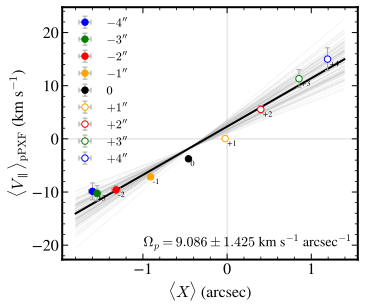

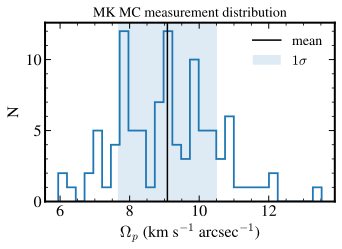

Saved MK MC figures to /home/jinelfy/TW_external/saved_outputs/MK_MC


In [48]:

# =========================================================
# 14. MK MC uncertainty plots
# =========================================================
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "cm",

    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    "axes.linewidth": 2.0,
    "legend.frameon": False,

    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

def plot_mk_mc_errorbars(
    slit_summary,
    fit_df,
    use_total_yerr=True,
    annotate_points=True,
):
    """
    Plot <V>--<X> for the MK method with MC-derived x/y error bars.
    """
    fig, ax = plt.subplots(figsize=(5.4, 4.6))

    yerr_col = "V_err_total" if use_total_yerr else "V_losvd_std"

    for _, row in slit_summary.iterrows():
        yoff = float(row["y_offset_arcsec"])
        st = _style_for_yabs(abs(yoff))
        marker = "o"
        face = "white" if yoff > 0 else st["color"]
        if np.isclose(yoff, 0.0):
            label = "0"
        elif yoff > 0:
            label = st["label_pos"]
        else:
            label = st["label_neg"]

        ax.errorbar(
            row["X_mean_arcsec_mean"],
            row["V_losvd_mean"],  
            xerr=row["X_mean_arcsec_std"],
            yerr=row[yerr_col],  #每个 slit 点的 errorbar 来自第 13 步的 mk_mc_slit_summary：
            fmt=marker,
            ms=6.5,
            color=st["color"],
            mfc=face,
            mec=st["color"],
            ecolor="0.65",
            elinewidth=1.0,
            capsize=2.5,
            label=label,
            zorder=3,
        )

        if annotate_points:
            slit_id = int(row["slit_id"])
            slit_label = "0" if slit_id == 0 else f"{slit_id:+d}"

            ax.text(
                row["X_mean_arcsec_mean"],
                row["V_losvd_mean"]-1,
                f" {slit_label}",
                fontsize=8,
                va="center",
            )

    # Light grey MC realisation fits.
    x = slit_summary["X_mean_arcsec_mean"].to_numpy(float)
    xline = np.linspace(np.nanmin(x) - 0.2, np.nanmax(x) + 0.2, 300)
    for _, r in fit_df.iterrows():
        if np.isfinite(r.get("slope_kms_per_arcsec", np.nan)) and np.isfinite(r.get("intercept_kms", np.nan)):
            ax.plot(   #每一次 MC 的灰色拟合线
                xline,
                r["slope_kms_per_arcsec"] * xline + r["intercept_kms"],
                color="0.75",
                lw=0.6,
                alpha=0.25,
                zorder=1,
            )

    # Mean MC relation.---画黑色的 mean relation：直接使用所有 MC fit 的 slope 和 intercept 的平均值
    slope_mean = np.nanmean(fit_df["slope_kms_per_arcsec"].to_numpy(float))
    intercept_mean = np.nanmean(fit_df["intercept_kms"].to_numpy(float))
    ax.plot(xline, slope_mean * xline + intercept_mean, "k-", lw=2.0, zorder=2)

    omega_label = ""
    if "slope_kms_per_arcsec" in fit_df.columns:
        om = fit_df["slope_kms_per_arcsec"].to_numpy(float)
        omega_label = (rf"$\Omega_p = {np.nanmean(om):.3f} \pm {np.nanstd(om, ddof=1):.3f}$ "
            + r"km s$^{-1}$ arcsec$^{-1}$"
        )

    ax.text(
        0.98, 0.1,
        omega_label,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14,
    )

    ax.axhline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.axvline(0.0, color="0.85", lw=1.0, zorder=0)
    ax.set_xlabel(r"$\langle X \rangle$ (arcsec)")
    ax.set_ylabel(r"$\langle V_{\parallel} \rangle_{\rm pPXF}$ (km s$^{-1}$)")
    # ax.set_title("MK method: MC PA uncertainty")
    ax.tick_params(direction="in", top=True, right=True)

    # Deduplicate legend labels.
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles_u, labels_u = [], []
    for h, lab in zip(handles, labels):
        if lab not in seen:
            handles_u.append(h)
            labels_u.append(lab)
            seen.add(lab)
    ax.legend(handles_u, labels_u, fontsize=12, frameon=False, loc="best")

    plt.tight_layout()
    return fig, ax

fig_mk_mc, ax_mk_mc = plot_mk_mc_errorbars(
    mk_mc_slit_summary,
    mk_mc_fit_df,
    use_total_yerr=False,
    annotate_points=True,
)
fig_mk_mc.savefig(mc_outdir / f"{galaxy_id}_OP_MK_MC_errorbars.png", dpi=300, bbox_inches="tight")
fig_mk_mc.savefig(mc_outdir / f"{galaxy_id}_OP_MK_MC_errorbars.pdf", bbox_inches="tight")
plt.show()


def plot_mk_mc_omega_hist(fit_df):
    """Plot the distribution of MC pattern-speed measurements in km/s/arcsec."""
    fig, ax = plt.subplots(figsize=(5.2, 3.8))

    col = "slope_kms_per_arcsec"
    xlabel = r"$\Omega_p$ (km s$^{-1}$ arcsec$^{-1}$)"

    vals = fit_df[col].to_numpy(float)
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=30, histtype="step", lw=1.8)
    ax.axvline(np.nanmean(vals), color="k", lw=1.5, label="mean")
    ax.axvspan(
        np.nanmean(vals) - np.nanstd(vals, ddof=1),
        np.nanmean(vals) + np.nanstd(vals, ddof=1),
        alpha=0.15,
        label=r"$1\sigma$",
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("N")
    ax.set_title("MK MC measurement distribution")
    ax.tick_params(direction="in", top=True, right=True)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax

fig_mk_mc_hist, ax_mk_mc_hist = plot_mk_mc_omega_hist(mk_mc_fit_df)
fig_mk_mc_hist.savefig(mc_outdir / f"{galaxy_id}_OP_MK_MC_omega_distribution.pdf", bbox_inches="tight")
fig_mk_mc_hist.savefig(mc_outdir / f"{galaxy_id}_OP_MK_MC_omega_distribution.pdf", bbox_inches="tight")
plt.show()

print(f"Saved MK MC figures to {mc_outdir.resolve()}")
